# GAIN / WGAN-FWAL / KD 결측치 대체 실험 — Light & Heavy DB

본 노트북은 **5개 Light 데이터셋 × 5개 결측률** 및 **2개 Heavy 데이터셋**에 대해
**GAIN**, **WGAN-FWAL**, **Knowledge Distillation(2단계)** 세 모델을 실행하고
**다중 성능 지표(RMSE, MAE, AUROC, PredAUC)** 및 **고급 평가(FLOPs, Latency, FID, Diversity)** 를 비교합니다.

| 데이터셋 | 결측률 |
|---|---|
| breast_cancer, spam, credit, wine, student | 0.05, 0.1, 0.2, 0.3, 0.5 |
| HIGGS, Criteo (Heavy) | 0.1, 0.2, 0.3 |

---
### 목차
1. 패키지 설치 및 임포트
2. 유틸리티 함수 (`utils.py`)
3. 성능 평가 함수 (`evaluation.py` + `advanced_eval.py`)
4. Light 데이터 로더 (`lightDBloader.py`)
5. Heavy 데이터 로더 (`heavyDBloader.py`)
6. 모델 정의 — GAIN
7. 모델 정의 — WGAN-FWAL
8. Knowledge Distillation — 2단계
9. Light DB 메인 실험 루프
10. Heavy DB 메인 실험 루프
11. 결과 시각화 (Light + Heavy 통합)
12. 고급 평가 — FLOPs / Latency / FID / Diversity


---
## 1. 패키지 설치 및 임포트

In [1]:
# 필요한 패키지 설치 (최초 1회)
!pip install torch pandas matplotlib seaborn scikit-learn ucimlrepo tqdm scipy


In [2]:
# 불필요한 경고 억제 (sklearn ConvergenceWarning, matplotlib 등)
import warnings
warnings.filterwarnings("ignore")

import os, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from torch.utils.data import Dataset, DataLoader
from ucimlrepo import fetch_ucirepo

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {DEVICE}')


PyTorch version : 2.0.1+cu118
CUDA available  : True
Using device    : cuda


---
## 2. 유틸리티 함수 (`utils.py`)


In [3]:
# ════════════════════════════════════════════════════════
# utils.py
# ════════════════════════════════════════════════════════

def normalization(data, parameters=None):
    """MinMax normalization to [0, 1]."""
    _, dim = data.shape
    norm_data = data.copy()

    if parameters is None:
        min_val = np.zeros(dim)
        max_val = np.zeros(dim)
        for i in range(dim):
            min_val[i] = np.nanmin(norm_data[:, i])
            norm_data[:, i] = norm_data[:, i] - min_val[i]
            max_val[i] = np.nanmax(norm_data[:, i])
            norm_data[:, i] = norm_data[:, i] / (max_val[i] + 1e-6)
        norm_parameters = {'min_val': min_val, 'max_val': max_val}
    else:
        min_val = parameters['min_val']
        max_val = parameters['max_val']
        for i in range(dim):
            norm_data[:, i] = norm_data[:, i] - min_val[i]
            norm_data[:, i] = norm_data[:, i] / (max_val[i] + 1e-6)
        norm_parameters = parameters

    return norm_data, norm_parameters


def renormalization(norm_data, norm_parameters):
    """역정규화: [0,1] → 원본 스케일."""
    min_val = norm_parameters['min_val']
    max_val = norm_parameters['max_val']
    _, dim = norm_data.shape
    renorm_data = norm_data.copy()
    for i in range(dim):
        renorm_data[:, i] = renorm_data[:, i] * (max_val[i] + 1e-6)
        renorm_data[:, i] = renorm_data[:, i] + min_val[i]
    return renorm_data


def rounding(imputed_data, data_x):
    """범주형 변수에 대해 반올림 처리."""
    _, dim = data_x.shape
    rounded_data = imputed_data.copy()
    for i in range(dim):
        temp = data_x[~np.isnan(data_x[:, i]), i]
        if len(np.unique(temp)) < 20:
            rounded_data[:, i] = np.round(rounded_data[:, i])
    return rounded_data


def rmse_loss(ori_data, imputed_data, data_m):
    """결측 위치에 대한 RMSE 계산."""
    ori_data, norm_parameters = normalization(ori_data)
    imputed_data, _ = normalization(imputed_data, norm_parameters)
    nominator   = np.sum(((1 - data_m) * ori_data - (1 - data_m) * imputed_data) ** 2)
    denominator = np.sum(1 - data_m)
    return np.sqrt(nominator / float(denominator))


def binary_sampler(p, rows, cols):
    """베르누이 샘플 행렬 생성."""
    return (np.random.uniform(0., 1., size=[rows, cols]) < p).astype(float)


def uniform_sampler(low, high, rows, cols):
    """균등분포 샘플 행렬 생성."""
    return np.random.uniform(low, high, size=[rows, cols])


def sample_batch_index(total, batch_size):
    """미니배치 인덱스 샘플링."""
    return np.random.permutation(total)[:batch_size]


print("✅ utils 함수 정의 완료")

✅ utils 함수 정의 완료


---
## 3. 성능 평가 함수 (`evaluation.py` + `advanced_eval.py`)

### 3-1. 기본 지표
| 함수 | 설명 |
|---|---|
| `rmse_loss` | 결측 위치 RMSE (정규화 후) |
| `mae_loss` | 결측 위치 MAE (정규화 후) |
| `auroc_score` | 결측 위치 실제값 이진화 → AUROC |
| `prediction_performance` | 마지막 컬럼 레이블 기준 5-fold CV AUC |
| `evaluate_all` | 위 4개 지표 딕셔너리로 반환 |

### 3-2. 고급 지표 (advanced_eval)
| 함수 | 설명 |
|---|---|
| `count_flops` / `count_parameters` | Linear layer 기준 FLOPs·파라미터 수 |
| `measure_latency` | 평균 추론 시간 (ms, 20회 반복) |
| `record_gradient_magnitudes` | 레이어별 gradient norm (학습 중 수집) |
| `compute_fid` | 간소화 FID (평균 벡터 차이 + 공분산 trace) |
| `diversity_score` | KS-test 기반 통계적 구별 피처 수 |
| `run_advanced_eval` | 위 고급 지표 + 그래프 일괄 생성 |


In [4]:
# ════════════════════════════════════════════════════════
# evaluation.py  — 기본 성능 평가 지표
# ════════════════════════════════════════════════════════

# ── 기본 지표 ────────────────────────────────────────────
def rmse_loss(ori_data, imputed_data, data_m):
    """결측 위치 RMSE (MinMax 정규화 후 계산)."""
    ori_norm, norm_params = normalization(ori_data)
    imp_norm, _           = normalization(imputed_data, norm_params)
    nom   = np.sum(((1 - data_m) * ori_norm - (1 - data_m) * imp_norm) ** 2)
    denom = np.sum(1 - data_m)
    return float(np.sqrt(nom / denom)) if denom > 0 else 0.0


def mae_loss(ori_data, imputed_data, data_m):
    """결측 위치 MAE (MinMax 정규화 후 계산)."""
    ori_norm, norm_params = normalization(ori_data)
    imp_norm, _           = normalization(imputed_data, norm_params)
    mask  = (1 - data_m)
    denom = np.sum(mask)
    return float(np.sum(np.abs(mask * ori_norm - mask * imp_norm)) / denom) if denom > 0 else 0.0


def auroc_score(ori_data, imputed_data, data_m):
    """결측 위치 실제값을 중앙값 기준 이진화 → AUROC."""
    ori_norm, norm_params = normalization(ori_data)
    imp_norm, _           = normalization(imputed_data, norm_params)
    mask = (1 - data_m).astype(bool)
    y_true_raw = ori_norm[mask]
    y_score    = imp_norm[mask]
    if len(y_true_raw) < 10:
        return float('nan')
    y_bin = (y_true_raw >= np.median(y_true_raw)).astype(int)
    if len(np.unique(y_bin)) < 2:
        return float('nan')
    try:
        return float(roc_auc_score(y_bin, y_score))
    except Exception:
        return float('nan')


def prediction_performance(ori_data, imputed_data):
    """마지막 컬럼을 레이블로 간주, 5-fold CV AUROC 측정."""
    try:
        X     = imputed_data[:, :-1]
        y     = ori_data[:, -1]
        unique = np.unique(y)
        if len(unique) < 2 or len(unique) > 20:
            return float('nan')

        # ✅ 핵심 수정: 반드시 0/1 정수로 강제 이진화
        median_val = np.nanmedian(y)
        y_bin = (y > median_val).astype(int)   # >= 대신 > 로 변경

        # ✅ 이진화 후에도 클래스 수 재확인
        if len(np.unique(y_bin)) < 2:
            return float('nan')

        # ✅ solver를 'lbfgs'로 변경 (multiclass도 처리 가능)
        clf    = LogisticRegression(
            solver='lbfgs',       # liblinear → lbfgs
            max_iter=2000,
            random_state=42
        )
        scores = cross_val_score(clf, X, y_bin, cv=5, scoring='roc_auc')
        return float(np.mean(scores))
    except Exception as e:
        print(f'PredAUC Error: {e}')
        return float('nan')


def evaluate_all(ori_data, imputed_data, data_m):
    """기본 4개 지표 딕셔너리 반환."""
    return {
        'rmse'    : rmse_loss(ori_data, imputed_data, data_m),
        'mae'     : mae_loss(ori_data, imputed_data, data_m),
        'auroc'   : auroc_score(ori_data, imputed_data, data_m),
        'pred_auc': prediction_performance(ori_data, imputed_data),
    }


# ── 결측률별 테이블 ─────────────────────────────────────────
def table_by_miss_rate(results_by_rate, metric, model_names, miss_rates):
    """
    results_by_rate[miss_rate][model] = {rmse, mae, ...}
    → 결측률별 지표 테이블 문자열 반환
    """
    col_w  = 10
    header = f"  {'Model':28s}" + ''.join(f'{r*100:>{col_w}.0f}%' for r in miss_rates) + f"{'avg':>{col_w}s}"
    sep    = '─' * len(header)
    lines  = [sep, f'  {metric.upper()} by Missing Rate', sep, header, sep]
    for m in model_names:
        vals = [results_by_rate.get(r, {}).get(m, {}).get(metric, np.nan) for r in miss_rates]
        avg  = np.nanmean(vals)
        row  = f'  {m:28s}'
        row += ''.join(f'{v:>{col_w}.4f}' if not np.isnan(v) else f"{'N/A':>{col_w}s}" for v in vals)
        row += f'{avg:>{col_w}.4f}'
        lines.append(row)
    lines.append(sep)
    return '\n'.join(lines)


def table_db_model_rmse(results_by_ds_rate, model_names, datasets, miss_rates):
    """
    results_by_ds_rate[ds][miss_rate][model] = {rmse,...}
    → DB별 모델별 mean±std RMSE 테이블
    """
    lines  = ['─'*90, '  RMSE: mean ± std  (across missing rates)', '─'*90]
    header = f"  {'Model':28s}" + ''.join(f'{d:>14s}' for d in datasets)
    lines += [header, '─'*90]
    for m in model_names:
        row = f'  {m:28s}'
        for ds in datasets:
            vals = [results_by_ds_rate.get(ds, {}).get(r, {}).get(m, {}).get('rmse', np.nan)
                    for r in miss_rates]
            vals = [v for v in vals if not np.isnan(v)]
            row += f'{np.mean(vals):>7.4f}±{np.std(vals):.4f}' if vals else f"{'N/A':>14s}"
        lines.append(row)
    lines.append('─'*90)
    return '\n'.join(lines)


def plot_rmse_by_miss_rate(results_by_rate, model_names, miss_rates, title, save_path=None):
    """결측률별 RMSE 라인 그래프."""
    colors = ['steelblue', 'seagreen', 'darkorange', 'tomato', 'mediumpurple']
    fig, ax = plt.subplots(figsize=(8, 5))
    for model, color in zip(model_names, colors):
        vals = [results_by_rate.get(r, {}).get(model, {}).get('rmse', np.nan) for r in miss_rates]
        ax.plot([r*100 for r in miss_rates], vals, marker='o',
                label=model, color=color, linewidth=2)
    ax.set_xlabel('Missing Rate (%)'); ax.set_ylabel('RMSE ↓')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


print('✅ evaluation 함수 정의 완료')


✅ evaluation 함수 정의 완료


In [5]:
# ════════════════════════════════════════════════════════
# advanced_eval.py  — 고급 평가 지표
# ════════════════════════════════════════════════════════

# ── FLOPs & Parameters ──────────────────────────────────
def count_flops(model, input_dim=None):
    total = 0
    for m in model.modules():
        if isinstance(m, nn.Linear):
            total += 2 * m.in_features * m.out_features
    return total

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


# ── Latency ──────────────────────────────────────────────
def measure_latency(G, norm_data_x, data_m, device, runs=20):
    no, dim = norm_data_x.shape
    times   = []
    G.eval()
    for _ in range(runs):
        Z  = np.random.uniform(0, 0.01, (no, dim))
        X  = data_m * norm_data_x + (1 - data_m) * Z
        Xt = torch.tensor(X,      dtype=torch.float32).to(device)
        Mt = torch.tensor(data_m, dtype=torch.float32).to(device)
        t0 = time.perf_counter()
        with torch.no_grad():
            G(Xt, Mt)
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(times)), float(np.std(times))


# ── Gradient Magnitude 기록 (학습 내부 수집용, 시각화 제거) ──
def record_gradient_magnitudes(model):
    grad_norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None and 'weight' in name:
            layer_id = name.split('.')[1] if '.' in name else 'out'
            grad_norms[f'Layer {layer_id}'] = param.grad.abs().mean().item()
    return grad_norms if grad_norms else {'none': 0.0}


# ── FID (간소화) ─────────────────────────────────────────
def compute_fid(real, fake):
    """FID ≈ ||μ_r - μ_g||² + Tr(Σ_r + Σ_g)"""
    mu_r, mu_g   = np.mean(real, axis=0), np.mean(fake, axis=0)
    cov_r, cov_g = np.cov(real.T), np.cov(fake.T)
    mean_diff    = float(np.sum((mu_r - mu_g) ** 2))
    if cov_r.ndim == 0:
        cov_trace = float(cov_r) + float(cov_g)
    else:
        cov_trace = np.trace(cov_r) + np.trace(cov_g)
    return float(mean_diff + cov_trace)


def plot_fid_convergence_single(fid_hist_gain, title='FID Convergence', save_path=None):
    """
    GAIN의 FID 수렴 곡선 단독 출력.
    (WGAN_FWAL은 학습 중 G를 반환하지 않으므로 FID history 없음)
    """
    if not fid_hist_gain:
        print(f'  [FID] history 없음 — 건너뜀: {title}')
        return
    fig, ax = plt.subplots(figsize=(8, 4))
    x = [i * CHECKPOINT_EVERY for i in range(1, len(fid_hist_gain) + 1)]
    ax.plot(x, fid_hist_gain, color='steelblue', linewidth=2, marker='o',
            markersize=3, label='GAIN')
    ax.set_xlabel('Iteration'); ax.set_ylabel('FID ↓')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()


def plot_fid_by_miss_rate(fid_hist_dict, miss_rates, title='FID Convergence by Miss Rate',
                           save_path=None):
    """
    결측률별 GAIN FID 수렴 곡선을 한 그래프에 겹쳐 비교.

    fid_hist_dict = {miss_rate: [fid_val, ...], ...}
    """
    cmap   = plt.cm.viridis
    colors = [cmap(i / max(len(miss_rates) - 1, 1)) for i in range(len(miss_rates))]

    fig, ax = plt.subplots(figsize=(9, 5))
    for (mr, hist), color in zip(fid_hist_dict.items(), colors):
        if not hist:
            continue
        x = [i * CHECKPOINT_EVERY for i in range(1, len(hist) + 1)]
        ax.plot(x, hist, linewidth=2, marker='o', markersize=3,
                label=f'miss={mr}', color=color)

    ax.set_xlabel('Iteration'); ax.set_ylabel('FID ↓')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(title='Missing Rate', fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()


def plot_fid_final_heatmap(fid_final_dict, title='Final FID by Dataset & Miss Rate',
                            save_path=None):
    """
    최종 FID 값을 데이터셋(행) × 결측률(열) 히트맵으로 비교.

    fid_final_dict = {ds: {miss_rate: fid_final_value, ...}, ...}
    """
    datasets   = list(fid_final_dict.keys())
    miss_rates = sorted({mr for d in fid_final_dict.values() for mr in d})
    matrix     = np.full((len(datasets), len(miss_rates)), np.nan)

    for i, ds in enumerate(datasets):
        for j, mr in enumerate(miss_rates):
            val = fid_final_dict[ds].get(mr)
            if val is not None:
                matrix[i, j] = val

    fig, ax = plt.subplots(figsize=(max(6, len(miss_rates) * 1.5),
                                    max(3, len(datasets) * 0.8)))
    im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(miss_rates)))
    ax.set_xticklabels([f'{mr}' for mr in miss_rates])
    ax.set_yticks(range(len(datasets)))
    ax.set_yticklabels(datasets)
    ax.set_xlabel('Missing Rate'); ax.set_ylabel('Dataset')
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Final FID ↓')

    for i in range(len(datasets)):
        for j in range(len(miss_rates)):
            if not np.isnan(matrix[i, j]):
                ax.text(j, i, f'{matrix[i, j]:.3f}', ha='center', va='center',
                        fontsize=8, color='black')
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()


# ── Diversity (KS-test 기반) ─────────────────────────────
def count_distinct_bins(real_missing, imputed_missing, alpha=0.05):
    if real_missing.ndim == 1:
        real_missing    = real_missing.reshape(-1, 1)
        imputed_missing = imputed_missing.reshape(-1, 1)
    distinct = 0
    for j in range(real_missing.shape[1]):
        r, g = real_missing[:, j], imputed_missing[:, j]
        if len(r) < 5 or np.std(r) < 1e-8:
            continue
        _, p = stats.ks_2samp(r, g)
        if p < alpha:
            distinct += 1
    return distinct

def diversity_score(ori_data, imputed_data, data_m):
    ori_norm, norm_params = normalization(ori_data)
    imp_norm, _           = normalization(imputed_data, norm_params)
    mask         = (1 - data_m).astype(bool)
    real_miss    = ori_norm[mask].reshape(-1, 1)
    imputed_miss = imp_norm[mask].reshape(-1, 1)
    return count_distinct_bins(real_miss, imputed_miss)


# ── 효율성 바 차트 ───────────────────────────────────────
def plot_efficiency_bars(metrics_dict, title='Efficiency Comparison', save_path=None):
    metric_keys   = ['params', 'flops', 'latency', 'diversity']
    metric_labels = ['Parameters', 'FLOPs', 'Latency (ms)', 'Distinct Bins ↓']
    model_names   = list(metrics_dict.keys())
    colors        = ['steelblue', 'seagreen', 'darkorange', 'tomato', 'mediumpurple']

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(title, fontsize=12, fontweight='bold')
    for ax, key, label in zip(axes, metric_keys, metric_labels):
        vals = [metrics_dict[m].get(key, 0) for m in model_names]
        bars = ax.bar(model_names, vals, color=colors[:len(model_names)], width=0.5)
        ax.set_title(label)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                    f'{v:.3g}', ha='center', va='bottom', fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()


print('✅ advanced_eval 함수 정의 완료')

✅ advanced_eval 함수 정의 완료


---
## 4. Light 데이터 로더 (`lightDBloader.py`)


In [6]:
# ════════════════════════════════════════════════════════
# lightDBloader.py
# ════════════════════════════════════════════════════════

UCI_DATA_IDS = {
    'breast_cancer': 14,
    'spam'         : 94,
    'credit'       : 222,
    'wine'         : 109,
    'student'      : 697
}


def get_gain_data(dataset_name, missing_rate, seed):
    """
    UCI 저장소에서 데이터를 받아 GAIN 실험용 numpy 배열을 반환합니다.

    Returns
    -------
    ori_data_x  : 원본 데이터 (결측 없음)
    miss_data_x : MCAR 결측치 주입 데이터 (NaN)
    data_m      : 마스크 행렬 (1=관측, 0=결측)
    """
    dataset_id = UCI_DATA_IDS[dataset_name]
    dataset    = fetch_ucirepo(id=dataset_id)
    X_df       = dataset.data.features.copy()

    # 자연 결측치 채우기
    for col in X_df.columns:
        if X_df[col].isnull().sum() > 0:
            if X_df[col].dtype == 'object':
                X_df[col] = X_df[col].fillna(X_df[col].mode()[0])
            else:
                X_df[col] = X_df[col].fillna(X_df[col].mean())

    X_df       = pd.get_dummies(X_df, drop_first=True)
    X_original = X_df.values.astype(float)

    # MCAR 결측치 생성
    np.random.seed(seed)
    mask        = (np.random.rand(*X_original.shape) > missing_rate).astype(float)
    X_corrupted = X_original.copy()
    X_corrupted[mask == 0] = np.nan

    return X_original, X_corrupted, mask


def plot_missing_heatmap(mask, dataset_name, missing_rate, save_path=None):
    """결측 패턴 히트맵 시각화."""
    plt.figure(figsize=(10, 6))
    sns.heatmap(mask, cmap='binary', cbar=False)
    plt.title(f"Missing Pattern ({dataset_name}, Rate={missing_rate*100:.0f}%)", fontsize=14)
    plt.xlabel("Features"); plt.ylabel("Instances")
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_data_distribution(X_orig, X_corr, feature_idx=0, save_path=None):
    """특정 피처에 대해 원본 vs 결측 처리 데이터 분포 비교."""
    plt.figure(figsize=(9, 4))
    corr_vals = X_corr[:, feature_idx]
    corr_vals = corr_vals[~np.isnan(corr_vals)]
    sns.kdeplot(X_orig[:, feature_idx], label='Original',  fill=True, color='steelblue', alpha=0.6)
    sns.kdeplot(corr_vals,              label='Corrupted', fill=True, color='tomato',    alpha=0.4, linestyle='--')
    plt.title(f"Distribution Comparison (Feature {feature_idx})")
    plt.legend()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print("✅ lightDBloader 함수 정의 완료")

✅ lightDBloader 함수 정의 완료


---
## 5. Heavy 데이터 로더 (`heavyDBloader.py`)

> 파일 경로 (노트북 기준 상위 디렉토리):  
> - HIGGS : `../data/HIGGS.csv`  
> - Criteo: `../criteoDB/train.txt`, `../criteoDB/test.txt`, `../criteoDB/readme.txt`


In [7]:
# ════════════════════════════════════════════════════════
# heavyDBloader.py
# ════════════════════════════════════════════════════════
import os
from sklearn.preprocessing import StandardScaler

# ── 파일 경로 (노트북 파일 기준 상위 폴더) ──────────────────────────
HIGGS_PATH   = os.path.join('.', 'data', 'HIGGS.csv')
CRITEO_TRAIN = os.path.join('.', 'data', 'criteoDB', 'train.txt')
CRITEO_TEST  = os.path.join('.', 'data', 'criteoDB', 'test.txt')
CRITEO_README= os.path.join('.', 'data', 'criteoDB', 'readme.txt')
# ────────────────────────────────────────────────────────


class HeavyImputationDataset(Dataset):
    """
    HIGGS / Criteo 대용량 데이터셋 로더.

    Parameters
    ----------
    file_path    : CSV(HIGGS) 또는 TSV(Criteo) 파일 경로
    missing_rate : MCAR 결측률
    seed         : 재현성 시드
    nrows        : 메모리 절약을 위해 읽을 최대 행 수 (기본 500,000)
    dataset_type : 'higgs' 또는 'criteo'
    """
    def __init__(self, file_path, missing_rate, seed,
                 nrows=500_000, dataset_type='higgs'):
        print(f"[{dataset_type.upper()}] Loading {nrows:,} rows from {file_path} ...")

        if not os.path.exists(file_path):
            raise FileNotFoundError(
                f"파일을 찾을 수 없습니다: {os.path.abspath(file_path)}\n"
                f"  HIGGS  → {os.path.abspath(HIGGS_PATH)}\n"
                f"  Criteo → {os.path.abspath(CRITEO_TRAIN)}"
            )

        sep    = '\t' if dataset_type == 'criteo' else ','
        header = None if dataset_type == 'criteo' else 'infer'

        df = pd.read_csv(file_path, sep=sep, nrows=nrows, header=header)
        # [버그수정] Criteo: col1~13만 수치형, col14~39는 hex → astype(float32) ValueError
        # 알고리즘 변경 없이 데이터 로드 오류만 수정
        if dataset_type == 'criteo':
            y_raw  = df.iloc[:, 0].values
            df_num = df.iloc[:, 1:14].apply(pd.to_numeric, errors='coerce')
            X_raw  = np.nan_to_num(df_num.values.astype(np.float32))
        else:
            y_raw = df.iloc[:, 0].values
            X_raw = np.nan_to_num(df.iloc[:, 1:].values.astype(np.float32))

        scaler     = StandardScaler()
        X_original = scaler.fit_transform(X_raw)          # float64

        self.X_orig = torch.from_numpy(X_original.astype(np.float32))
        self.y      = torch.from_numpy(y_raw.astype(np.int64))

        # MCAR 마스크 생성 (1=관측, 0=결측)
        np.random.seed(seed)
        mask_np  = (np.random.rand(*X_original.shape) > missing_rate).astype(np.float32)
        self.mask = torch.from_numpy(mask_np)

        # 결측 위치를 0으로 채운 corrupted 버전
        self.X_corr = self.X_orig.clone()
        self.X_corr[self.mask == 0] = 0.0

        print(f"[{dataset_type.upper()}] 로드 완료. Shape: {tuple(self.X_orig.shape)}")

    def __len__(self):
        return len(self.X_orig)

    def __getitem__(self, idx):
        return self.X_orig[idx], self.X_corr[idx], self.mask[idx], self.y[idx]


def get_heavy_dataloader(dataset_name, missing_rate, seed,
                         batch_size=512, nrows=500_000, split='train'):
    """
    HIGGS / Criteo DataLoader 반환.

    Parameters
    ----------
    dataset_name : 'higgs' 또는 'criteo'
    missing_rate : MCAR 결측률
    seed         : 재현성 시드
    batch_size   : 미니배치 크기 (기본 512)
    nrows        : 읽을 최대 행 수 (기본 500,000)
    split        : 'train' 또는 'test'  (Criteo 전용, HIGGS는 단일 파일)

    Returns
    -------
    loader : torch DataLoader
    """
    if dataset_name.lower() == 'higgs':
        file_path = HIGGS_PATH
    elif dataset_name.lower() == 'criteo':
        file_path = CRITEO_TRAIN if split == 'train' else CRITEO_TEST
    else:
        raise ValueError("dataset_name 은 'higgs' 또는 'criteo' 이어야 합니다.")

    dataset = HeavyImputationDataset(
        file_path=file_path,
        missing_rate=missing_rate,
        seed=seed,
        nrows=nrows,
        dataset_type=dataset_name.lower()
    )
    loader = DataLoader(dataset, batch_size=batch_size,
                        shuffle=(split == 'train'), num_workers=0,
                        pin_memory=torch.cuda.is_available())
    return loader


def plot_heavy_missing_heatmap(mask, dataset_name, missing_rate,
                               sample_size=1000, save_path=None):
    """대용량 데이터 결측 패턴 히트맵 (앞 sample_size 행만 표시)."""
    if isinstance(mask, torch.Tensor):
        mask = mask.numpy()
    plot_data = mask[:sample_size, :]

    plt.figure(figsize=(12, 8))
    sns.heatmap(plot_data, cmap='binary', cbar=False)
    plt.title(f"Missing Pattern Sample ({dataset_name}, "
              f"Rate={missing_rate*100:.0f}%, N={sample_size})", fontsize=14)
    plt.xlabel('Feature Index'); plt.ylabel('Sample Index')
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_heavy_distribution(X_orig, X_corr, feature_idx=0,
                            sample_size=5000, save_path=None):
    """대용량 데이터의 특정 피처에 대해 원본 vs 결측 처리 분포 비교."""
    if isinstance(X_orig, torch.Tensor): X_orig = X_orig.numpy()
    if isinstance(X_corr, torch.Tensor): X_corr = X_corr.numpy()

    indices  = np.random.choice(len(X_orig), min(sample_size, len(X_orig)), replace=False)
    s_orig   = X_orig[indices, feature_idx]
    s_corr   = X_corr[indices, feature_idx]
    s_corr   = s_corr[s_corr != 0]          # 결측(0으로 채운) 위치 제외

    plt.figure(figsize=(9, 4))
    sns.kdeplot(s_orig,  label='Original',  fill=True, color='steelblue', alpha=0.6)
    sns.kdeplot(s_corr,  label='Corrupted', fill=True, color='tomato',    alpha=0.4,
                linestyle='--')
    plt.title(f"Feature Distribution — Feature {feature_idx} (N={sample_size})")
    plt.xlabel('Standardized Value'); plt.ylabel('Density')
    plt.legend()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print("✅ heavyDBloader 함수 정의 완료")
print(f"  HIGGS   경로 확인: {os.path.abspath(HIGGS_PATH)}")
print(f"  Criteo  경로 확인: {os.path.abspath(CRITEO_TRAIN)}")


✅ heavyDBloader 함수 정의 완료
  HIGGS   경로 확인: /root/GAIN/data/HIGGS.csv
  Criteo  경로 확인: /root/GAIN/data/criteoDB/train.txt


### (선택) Heavy 데이터 로더 사용 예시

> 아래 셀은 실제 HIGGS/Criteo 파일이 있을 때만 실행하세요.  
> 파일이 없으면 건너뛰어도 이후 Light 실험에 영향 없습니다.

[HIGGS] Loading 200,000 rows from ./data/HIGGS.csv ...
[HIGGS] 로드 완료. Shape: (200000, 28)
X_orig shape : torch.Size([512, 28])
mask  shape  : torch.Size([512, 28])


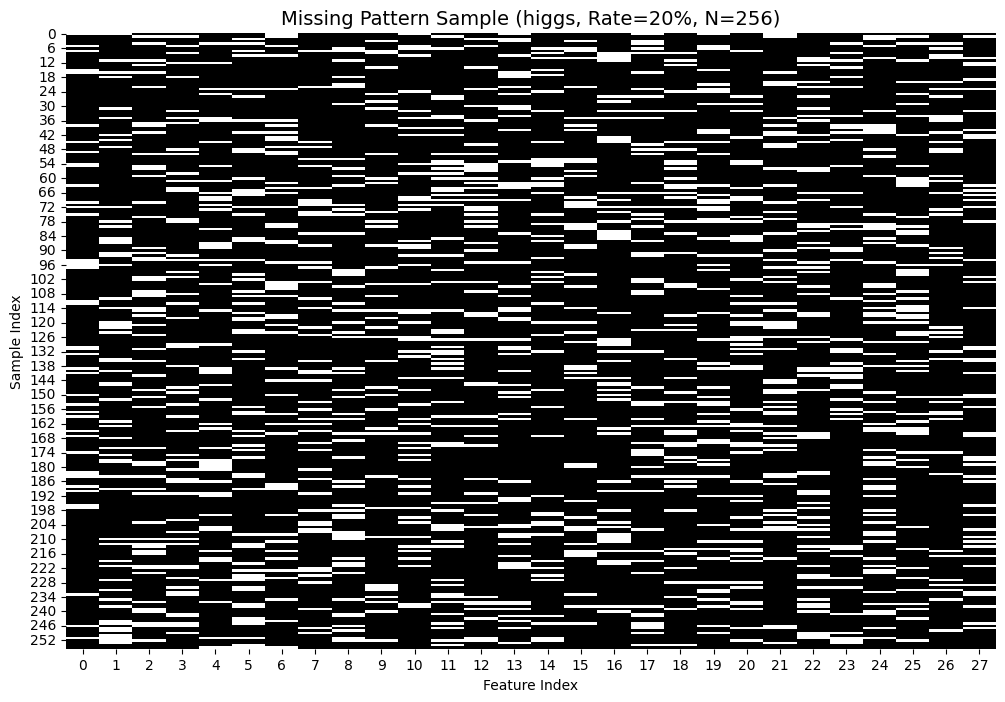

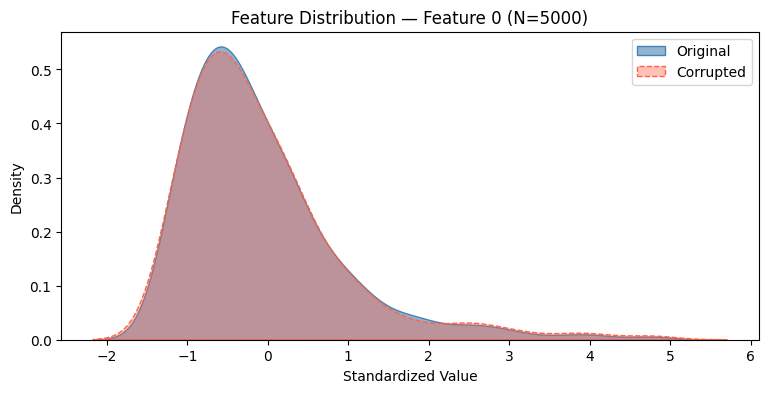

In [8]:
# ── Heavy 데이터셋 사용 예시 (파일 존재 시에만 실행) ──
HEAVY_DATASET = 'higgs'   # 또는 'criteo'
HEAVY_MISS    = 0.2
HEAVY_NROWS   = 200_000   # RAM에 맞게 조정

loader = get_heavy_dataloader(
    dataset_name = HEAVY_DATASET,
    missing_rate = HEAVY_MISS,
    seed         = 42,
    batch_size   = 512,
    nrows        = HEAVY_NROWS
)

# 첫 배치 확인
X_orig_b, X_corr_b, mask_b, y_b = next(iter(loader))
print('X_orig shape :', X_orig_b.shape)
print('mask  shape  :', mask_b.shape)

# 결측 패턴 시각화
plot_heavy_missing_heatmap(mask_b, HEAVY_DATASET, HEAVY_MISS, sample_size=256)
plot_heavy_distribution(X_orig_b, X_corr_b, feature_idx=0)
# print("Heavy 데이터셋 사용 시 위 주석을 해제하세요.")

---
## 6. 모델 정의 — GAIN (`model_GAIN.py`)


In [9]:
# ════════════════════════════════════════════════════════
# model_GAIN.py
# ════════════════════════════════════════════════════════

class GAINGenerator(nn.Module):
    """GAIN Generator: (X, M) → imputed values."""
    def __init__(self, dim, h_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim * 2, h_dim), nn.ReLU(),
            nn.Linear(h_dim, h_dim),   nn.ReLU(),
            nn.Linear(h_dim, dim),     nn.Sigmoid()
        )
        self._init_weights()

    def _init_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x, m):
        return self.net(torch.cat([x, m], dim=1))


class GAINDiscriminator(nn.Module):
    """GAIN Discriminator: (X_hat, H) → observed/imputed probability."""
    def __init__(self, dim, h_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim * 2, h_dim), nn.ReLU(),
            nn.Linear(h_dim, h_dim),   nn.ReLU(),
            nn.Linear(h_dim, dim),     nn.Sigmoid()
        )
        self._init_weights()

    def _init_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x, h):
        return self.net(torch.cat([x, h], dim=1))


def gain(data_x, gain_parameters):
    """
    GAIN 기반 결측치 대체 (PyTorch).

    Parameters
    ----------
    data_x          : 결측치가 포함된 numpy 배열
    gain_parameters : dict {batch_size, hint_rate, alpha, iterations, device}

    Returns
    -------
    imputed_data : 대체 완료된 numpy 배열
    """
    device = torch.device(gain_parameters.get('device', 'cpu'))
    data_m = 1 - np.isnan(data_x)

    batch_size = gain_parameters['batch_size']
    hint_rate  = gain_parameters['hint_rate']
    alpha      = gain_parameters['alpha']
    iterations = gain_parameters['iterations']

    no, dim = data_x.shape
    h_dim   = dim

    norm_data, norm_parameters = normalization(data_x)
    norm_data_x = np.nan_to_num(norm_data, nan=0.0)

    generator     = GAINGenerator(dim, h_dim).to(device)
    discriminator = GAINDiscriminator(dim, h_dim).to(device)
    D_optimizer   = optim.Adam(discriminator.parameters())
    G_optimizer   = optim.Adam(generator.parameters())

    for it in tqdm(range(iterations), desc="[GAIN] Training", leave=False):
        batch_idx  = sample_batch_index(no, batch_size)
        X_mb       = norm_data_x[batch_idx, :]
        M_mb       = data_m[batch_idx, :]
        Z_mb       = uniform_sampler(0, 0.01, batch_size, dim)
        H_mb       = M_mb * binary_sampler(hint_rate, batch_size, dim)
        X_mb       = M_mb * X_mb + (1 - M_mb) * Z_mb

        X_t = torch.tensor(X_mb, dtype=torch.float32).to(device)
        M_t = torch.tensor(M_mb, dtype=torch.float32).to(device)
        H_t = torch.tensor(H_mb, dtype=torch.float32).to(device)

        # Discriminator step
        discriminator.train(); generator.eval()
        with torch.no_grad():
            G_sample = generator(X_t, M_t)
        Hat_X  = X_t * M_t + G_sample * (1 - M_t)
        D_prob = discriminator(Hat_X.detach(), H_t)
        D_loss = -torch.mean(
            M_t * torch.log(D_prob + 1e-8) +
            (1 - M_t) * torch.log(1.0 - D_prob + 1e-8)
        )
        D_optimizer.zero_grad(); D_loss.backward(); D_optimizer.step()

        # Generator step
        generator.train(); discriminator.eval()
        G_sample    = generator(X_t, M_t)
        Hat_X       = X_t * M_t + G_sample * (1 - M_t)
        D_prob      = discriminator(Hat_X, H_t)
        G_loss_adv  = -torch.mean((1 - M_t) * torch.log(D_prob + 1e-8))
        MSE_loss    = torch.mean((M_t * X_t - M_t * G_sample) ** 2) / torch.mean(M_t)
        G_loss      = G_loss_adv + alpha * MSE_loss
        G_optimizer.zero_grad(); G_loss.backward(); G_optimizer.step()

    # Inference
    generator.eval()
    Z_inf = uniform_sampler(0, 0.01, no, dim)
    X_inf = data_m * norm_data_x + (1 - data_m) * Z_inf
    with torch.no_grad():
        imputed = generator(
            torch.tensor(X_inf, dtype=torch.float32).to(device),
            torch.tensor(data_m, dtype=torch.float32).to(device)
        ).cpu().numpy()

    imputed = data_m * norm_data_x + (1 - data_m) * imputed
    imputed = renormalization(imputed, norm_parameters)
    imputed = rounding(imputed, data_x)
    return imputed



def train_gain_with_history(data_x, gain_parameters, g_hist=None, f_hist=None):
    """
    GAIN 훈련 + (Generator, imputed_data) 반환.
    gain()와 동일한 훈련 로직이지만 학습된 Generator 모델도 함께 반환.
    g_hist / f_hist 는 선택적 기록 리스트 (빈 채로 전달하면 채워주지 않음).
    """
    if g_hist is None: g_hist = []
    if f_hist is None: f_hist = []

    device = torch.device(gain_parameters.get('device', 'cpu'))
    data_m = 1 - np.isnan(data_x)

    batch_size = gain_parameters['batch_size']
    hint_rate  = gain_parameters['hint_rate']
    alpha      = gain_parameters['alpha']
    iterations = gain_parameters['iterations']

    no, dim = data_x.shape
    h_dim   = dim

    norm_data, norm_parameters = normalization(data_x)
    norm_data_x = np.nan_to_num(norm_data, nan=0.0)

    generator     = GAINGenerator(dim, h_dim).to(device)
    discriminator = GAINDiscriminator(dim, h_dim).to(device)
    D_optimizer   = optim.Adam(discriminator.parameters())
    G_optimizer   = optim.Adam(generator.parameters())

    for it in tqdm(range(iterations), desc="[GAIN] Training", leave=False):
        batch_idx = sample_batch_index(no, batch_size)
        X_mb = norm_data_x[batch_idx, :]
        M_mb = data_m[batch_idx, :]
        Z_mb = uniform_sampler(0, 0.01, batch_size, dim)
        H_mb = M_mb * binary_sampler(hint_rate, batch_size, dim)
        X_mb = M_mb * X_mb + (1 - M_mb) * Z_mb

        X_t = torch.tensor(X_mb, dtype=torch.float32).to(device)
        M_t = torch.tensor(M_mb, dtype=torch.float32).to(device)
        H_t = torch.tensor(H_mb, dtype=torch.float32).to(device)

        discriminator.train(); generator.eval()
        with torch.no_grad():
            G_sample = generator(X_t, M_t)
        Hat_X  = X_t * M_t + G_sample * (1 - M_t)
        D_prob = discriminator(Hat_X.detach(), H_t)
        D_loss = -torch.mean(
            M_t * torch.log(D_prob + 1e-8) +
            (1 - M_t) * torch.log(1.0 - D_prob + 1e-8)
        )
        D_optimizer.zero_grad(); D_loss.backward(); D_optimizer.step()

        generator.train(); discriminator.eval()
        G_sample   = generator(X_t, M_t)
        Hat_X      = X_t * M_t + G_sample * (1 - M_t)
        D_prob     = discriminator(Hat_X, H_t)
        G_loss_adv = -torch.mean((1 - M_t) * torch.log(D_prob + 1e-8))
        MSE_loss   = torch.mean((M_t * X_t - M_t * G_sample) ** 2) / torch.mean(M_t)
        G_loss     = G_loss_adv + alpha * MSE_loss
        G_optimizer.zero_grad(); G_loss.backward(); G_optimizer.step()

    # Inference
    generator.eval()
    Z_inf = uniform_sampler(0, 0.01, no, dim)
    X_inf = data_m * norm_data_x + (1 - data_m) * Z_inf
    with torch.no_grad():
        imputed = generator(
            torch.tensor(X_inf, dtype=torch.float32).to(device),
            torch.tensor(data_m, dtype=torch.float32).to(device)
        ).cpu().numpy()

    imputed = data_m * norm_data_x + (1 - data_m) * imputed
    imputed = renormalization(imputed, norm_parameters)
    imputed = rounding(imputed, data_x)
    return generator, imputed

print("✅ GAIN 모델 정의 완료")

✅ GAIN 모델 정의 완료


---
## 7. 모델 정의 — WGAN-FWAL (`model_WGANwithFWAL.py`)


In [10]:
# ════════════════════════════════════════════════════════
# model_WGANwithFWAL.py
# ════════════════════════════════════════════════════════

class FWALGenerator(nn.Module):
    def __init__(self, dim, h_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim * 2, h_dim), nn.ReLU(),
            nn.Linear(h_dim, h_dim),   nn.ReLU(),
            nn.Linear(h_dim, dim),     nn.Sigmoid()
        )
        self._init_weights()

    def _init_weights(self):
        for l in self.net:
            if isinstance(l, nn.Linear):
                nn.init.xavier_normal_(l.weight); nn.init.zeros_(l.bias)

    def forward(self, x, m):
        return self.net(torch.cat([x, m], dim=1))


from torch.nn.utils import spectral_norm

class FWALCritic(nn.Module):
    def __init__(self, dim, h_dim):
        super().__init__()
        self.net = nn.Sequential(
            spectral_norm(nn.Linear(dim * 2, h_dim)), nn.ReLU(),
            spectral_norm(nn.Linear(h_dim, h_dim)),   nn.ReLU(),
            spectral_norm(nn.Linear(h_dim, dim))
        )
        self._init_weights()

    def _init_weights(self):
        # spectral_norm 적용 후에는 weight_orig에 접근해야 함
        for l in self.net:
            if isinstance(l, nn.Linear):
                nn.init.xavier_normal_(l.weight_orig)
                nn.init.zeros_(l.bias)

    def forward(self, x, h):
        return self.net(torch.cat([x, h], dim=1))


def _gradient_penalty_fwal(critic, real, fake, h, device):
    """Feature-wise Gradient Penalty 계산."""
    alpha       = torch.rand(real.size(0), 1).to(device)
    interpolate = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interp    = critic(interpolate, h)
    grads       = torch.autograd.grad(
        outputs=d_interp, inputs=interpolate,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    grads = grads.view(grads.size(0), -1)
    return ((grads.norm(2, dim=1) - 1) ** 2).mean()


def wganwithFWAL(data_x, gain_parameters):
    """
    Feature-wise Adversarial Loss를 적용한 WGAN-GP 결측치 대체.

    Parameters
    ----------
    data_x          : 결측치가 포함된 numpy 배열
    gain_parameters : dict {batch_size, hint_rate, alpha, iterations, device}

    Returns
    -------
    imputed_data : 대체 완료된 numpy 배열
    """
    device     = torch.device(gain_parameters.get('device', 'cpu'))
    data_m     = 1 - np.isnan(data_x)
    batch_size = gain_parameters['batch_size']
    hint_rate  = gain_parameters['hint_rate']
    alpha_gain = gain_parameters['alpha']
    iterations = gain_parameters['iterations']
    lambda_gp  = 10.0
    n_critic   = 5

    no, dim = data_x.shape
    h_dim   = dim

    norm_data, norm_parameters = normalization(data_x)
    norm_data_x = np.nan_to_num(norm_data, nan=0.0)

    generator = FWALGenerator(dim, h_dim).to(device)
    critic    = FWALCritic(dim, h_dim).to(device)
    _lr       = gain_parameters.get('lr', 1e-4)
    use_coslr = gain_parameters.get('use_coslr', True)  # False → CosLR 비적용
    G_opt = optim.Adam(generator.parameters(), lr=_lr, betas=(0.5, 0.9))
    C_opt = optim.Adam(critic.parameters(),    lr=_lr, betas=(0.5, 0.9))
    if use_coslr:
        G_sched = torch.optim.lr_scheduler.CosineAnnealingLR(G_opt, T_max=iterations, eta_min=_lr*0.01)
        C_sched = torch.optim.lr_scheduler.CosineAnnealingLR(C_opt, T_max=iterations, eta_min=_lr*0.01)

    for it in tqdm(range(iterations), desc="[WGAN-FWAL] Training", leave=False):
        for _ in range(n_critic):
            batch_idx  = sample_batch_index(no, batch_size)
            X_mb       = norm_data_x[batch_idx, :]
            M_mb       = data_m[batch_idx, :]
            Z_mb       = uniform_sampler(0, 0.01, batch_size, dim)
            H_mb       = M_mb * binary_sampler(hint_rate, batch_size, dim)
            X_mb_noisy = M_mb * X_mb + (1 - M_mb) * Z_mb

            X_t = torch.tensor(X_mb_noisy, dtype=torch.float32).to(device)
            M_t = torch.tensor(M_mb,       dtype=torch.float32).to(device)
            H_t = torch.tensor(H_mb,       dtype=torch.float32).to(device)

            with torch.no_grad():
                G_sample = generator(X_t, M_t)
            Hat_X   = X_t * M_t + G_sample * (1 - M_t)
            C_score = critic(Hat_X, H_t)

            # Feature-wise WGAN loss: 실제(M=1) ↑, 생성(M=0) ↓
            C_loss  = (torch.mean((1 - M_t) * C_score) - torch.mean(M_t * C_score)
                       + lambda_gp * _gradient_penalty_fwal(critic, X_t, Hat_X, H_t, device))
            C_opt.zero_grad(); C_loss.backward(); C_opt.step()

        # [수정-C18-1] Critic 마지막 배치(X_t,M_t)를 그대로 재사용하면
        # G가 Critic이 본 데이터에만 과적합됨 → 독립적인 새 배치로 분리
        g_idx      = sample_batch_index(no, batch_size)
        X_g        = norm_data_x[g_idx, :]
        M_g        = data_m[g_idx, :]
        Z_g        = uniform_sampler(0, 0.01, batch_size, dim)
        H_g        = M_g * binary_sampler(hint_rate, batch_size, dim)
        X_g_noisy  = M_g * X_g + (1 - M_g) * Z_g
        X_t = torch.tensor(X_g_noisy, dtype=torch.float32).to(device)
        M_t = torch.tensor(M_g,       dtype=torch.float32).to(device)
        H_t = torch.tensor(H_g,       dtype=torch.float32).to(device)

        G_sample   = generator(X_t, M_t)
        Hat_X      = X_t * M_t + G_sample * (1 - M_t)
        C_score    = critic(Hat_X, H_t)
        G_loss_adv = -torch.mean((1 - M_t) * C_score)
        MSE_loss   = torch.mean((M_t * X_t - M_t * G_sample) ** 2) / (torch.mean(M_t) + 1e-8)
        G_loss     = G_loss_adv + alpha_gain * MSE_loss
        # [수정-GradClip] G gradient explode 방지 (GAN 학습 안정화)
        G_opt.zero_grad(); G_loss.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
        G_opt.step()
        if use_coslr:
            G_sched.step()
            C_sched.step()

    generator.eval()
    with torch.no_grad():
        imputed = generator(
            torch.tensor(norm_data_x, dtype=torch.float32).to(device),
            torch.tensor(data_m,      dtype=torch.float32).to(device)
        ).cpu().numpy()

    imputed = data_m * norm_data_x + (1 - data_m) * imputed
    imputed = renormalization(imputed, norm_parameters)
    imputed = rounding(imputed, data_x)
    # [수정-C18-2] Generator 객체도 함께 반환 → KD에서 실제 Teacher로 직접 재사용
    return imputed, generator


print("✅ WGAN-FWAL 모델 정의 완료")

✅ WGAN-FWAL 모델 정의 완료


---
## 8. Knowledge Distillation — 2단계 (`model_KD.py`)

> **1단계 (Hard-label)**: Teacher(WGAN-FWAL) imputed output → Student MSE  
> **2단계 (Soft+Feature)**: Teacher 중간 feature L2 + KL Divergence  


In [11]:
# ════════════════════════════════════════════════════════
# model_KD.py  —  2단계 Knowledge Distillation
# ════════════════════════════════════════════════════════
import torch.nn.functional as F


# ── Student Generator (경량 버전) ──────────────────────
class StudentGenerator(nn.Module):
    """
    Teacher(FWALGenerator)보다 작은 경량 Generator.
    hidden dim = dim // 2 로 파라미터 수를 약 1/4 로 줄임.
    """
    def __init__(self, dim, h_dim=None):
        super().__init__()
        h_dim = h_dim or max(dim // 2, 16)
        self.fc1 = nn.Linear(dim * 2, h_dim)
        self.fc2 = nn.Linear(h_dim, h_dim)
        self.fc3 = nn.Linear(h_dim, dim)
        self._init_weights()

    def _init_weights(self):
        for layer in [self.fc1, self.fc2, self.fc3]:
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x, m, return_feat=False):
        inp  = torch.cat([x, m], dim=1)
        h1   = F.relu(self.fc1(inp))
        feat = F.relu(self.fc2(h1))   # feature map (KD에서 사용)
        out  = torch.sigmoid(self.fc3(feat))
        if return_feat:
            return out, feat
        return out


# ── Teacher feature hook ───────────────────────────────
class _FeatureHook:
    """Teacher 중간 레이어 출력을 캡처하는 forward hook."""
    def __init__(self):
        self.feat = None

    def hook_fn(self, module, inp, output):
        self.feat = output


# ── 1단계: Hard-label Distillation ────────────────────
def kd_stage1(teacher_gen, student_gen, norm_data_x, data_m,
               device, params):
    """
    1단계 KD: Teacher imputed output을 pseudo-label로 사용.

    Loss = MSE(student_out, teacher_out)  +  alpha * MSE(student_out, observed)
    """
    batch_size = params['batch_size']
    alpha      = params.get('kd_alpha', 1.0)
    iters      = params.get('kd_stage1_iters', 3000)
    no, dim    = norm_data_x.shape

    optimizer = optim.Adam(student_gen.parameters(), lr=1e-3)
    teacher_gen.eval()
    student_gen.train()

    for it in tqdm(range(iters), desc="[KD Stage-1] Hard-label", leave=False):
        idx  = sample_batch_index(no, batch_size)
        X_mb = norm_data_x[idx, :]
        M_mb = data_m[idx, :]
        Z_mb = uniform_sampler(0, 0.01, batch_size, dim)
        X_in = M_mb * X_mb + (1 - M_mb) * Z_mb

        X_t  = torch.tensor(X_in,  dtype=torch.float32).to(device)
        M_t  = torch.tensor(M_mb,  dtype=torch.float32).to(device)
        X_obs= torch.tensor(X_mb,  dtype=torch.float32).to(device)

        with torch.no_grad():
            t_out = teacher_gen(X_t, M_t)       # Teacher pseudo-label

        s_out = student_gen(X_t, M_t)

        # Pseudo-label loss (결측 위치)
        missing_count = (1 - M_t).sum() + 1e-8
        loss_pseudo   = ((1 - M_t) * (s_out - t_out) ** 2).sum() / missing_count
        # Reconstruction loss (관측 위치)
        loss_recon   = torch.mean(M_t * (s_out - X_obs) ** 2) / (M_t.mean() + 1e-8)
        loss         = loss_pseudo + alpha * loss_recon

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return student_gen


# ── 2단계: Soft-label + Feature Distillation ──────────
def kd_stage2(teacher_gen, student_gen, norm_data_x, data_m,
               device, params):
    """
    2단계 KD: Feature-map L2 + KL Divergence 손실 추가.

    Loss = w_feat * L2(s_feat, t_feat)
         + w_kl  * KL(softmax(s_out/T) || softmax(t_out/T))
         + alpha * MSE(s_out, observed)
    """
    batch_size = params['batch_size']
    alpha      = params.get('kd_alpha', 1.0)
    iters      = params.get('kd_stage2_iters', 3000)
    T          = params.get('kd_temperature', 3.0)   # softmax temperature
    w_feat     = params.get('kd_w_feat', 0.5)
    w_kl       = params.get('kd_w_kl',  0.5)
    no, dim    = norm_data_x.shape

    # Teacher 중간 feature 추출을 위한 hook 등록
    hook = _FeatureHook()
    # FWALGenerator.net[3] = 2번째 ReLU (두 번째 hidden layer 출력)
    handle = teacher_gen.net[3].register_forward_hook(hook.hook_fn)

    optimizer = optim.Adam(student_gen.parameters(), lr=5e-4)
    teacher_gen.eval()
    student_gen.train()

    for it in tqdm(range(iters), desc="[KD Stage-2] Soft+Feature", leave=False):
        idx  = sample_batch_index(no, batch_size)
        X_mb = norm_data_x[idx, :]
        M_mb = data_m[idx, :]
        Z_mb = uniform_sampler(0, 0.01, batch_size, dim)
        X_in = M_mb * X_mb + (1 - M_mb) * Z_mb

        X_t  = torch.tensor(X_in,  dtype=torch.float32).to(device)
        M_t  = torch.tensor(M_mb,  dtype=torch.float32).to(device)
        X_obs= torch.tensor(X_mb,  dtype=torch.float32).to(device)

        with torch.no_grad():
            t_out  = teacher_gen(X_t, M_t)
            t_feat = hook.feat.detach()          # Teacher feature map

        s_out, s_feat = student_gen(X_t, M_t, return_feat=True)

        # Feature-map L2 distillation (차원 맞추기: linear projection)
        if s_feat.shape[1] != t_feat.shape[1]:
            # 첫 호출 시 projection layer 생성 (한 번만)
            if not hasattr(kd_stage2, '_proj'):
                kd_stage2._proj = nn.Linear(
                    s_feat.shape[1], t_feat.shape[1], bias=False
                ).to(device)
            s_feat_proj = kd_stage2._proj(s_feat)
        else:
            s_feat_proj = s_feat
        loss_feat = F.mse_loss(s_feat_proj, t_feat)

        # [수정-C20-1] KL div는 분류 확률분포용이므로 연속값 imputation에 부적합
        # (모든 피처 출력에 softmax → 피처 간 합계=1 강제, 의미 없음)
        # temperature-scaled MSE soft distillation으로 대체
        loss_kl = torch.mean((1 - M_t) * (s_out / T - t_out / T) ** 2) * (T ** 2)

        # Reconstruction loss (관측 위치)
        loss_recon = torch.mean(M_t * (s_out - X_obs) ** 2) / (M_t.mean() + 1e-8)

        loss = w_feat * loss_feat + w_kl * loss_kl + alpha * loss_recon
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    handle.remove()   # hook 해제
    if hasattr(kd_stage2, '_proj'):
        del kd_stage2._proj
    return student_gen


# ── 통합 KD 파이프라인 ────────────────────────────────
def knowledge_distillation(data_x, gain_parameters):
    """
    2단계 Knowledge Distillation 결측치 대체.

    Parameters
    ----------
    data_x          : 결측치가 포함된 numpy 배열
    gain_parameters : dict {
        batch_size, hint_rate, alpha, iterations, device,
        kd_alpha          (default 1.0),
        kd_stage1_iters   (default iterations // 2),
        kd_stage2_iters   (default iterations // 2),
        kd_temperature    (default 3.0),
        kd_w_feat         (default 0.5),
        kd_w_kl           (default 0.5),
    }

    Returns
    -------
    imputed_data : 대체 완료된 numpy 배열
    """
    device     = torch.device(gain_parameters.get('device', 'cpu'))
    data_m     = 1 - np.isnan(data_x)
    iterations = gain_parameters['iterations']

    # stage 분할 기본값
    gain_parameters.setdefault('kd_stage1_iters', iterations // 2)
    gain_parameters.setdefault('kd_stage2_iters', iterations // 2)

    no, dim = data_x.shape
    norm_data, norm_parameters = normalization(data_x)
    norm_data_x = np.nan_to_num(norm_data, nan=0.0)

    # ── Step 0: Teacher 학습 (WGAN-FWAL) ──
    print("[KD] Teacher(WGAN-FWAL) 학습 중 ...")
    # [수정-C20-2] wganwithFWAL이 이제 (imputed, generator) 튜플을 반환
    # 기존: imputed numpy만 받아 랜덤 초기화 net을 10번 fine-tune한 _TeacherWrapper 사용
    #       → 완전히 새로운 네트워크라 실제 Teacher와 무관한 Proxy일 뿐
    # 수정: 학습 완료된 FWALGenerator를 직접 Teacher로 사용 → 진짜 KD
    teacher_out_np, teacher_gen = wganwithFWAL(data_x, gain_parameters)
    teacher_gen.eval()
    for p in teacher_gen.parameters():
        p.requires_grad = False   # Teacher 가중치 동결 (Student 업데이트에 영향 없게)

    # ── Step 1: Hard-label Distillation ──
    print("[KD] Stage 1 — Hard-label Distillation ...")
    student_gen = StudentGenerator(dim).to(device)
    student_gen = kd_stage1(teacher_gen, student_gen,
                             norm_data_x, data_m, device, gain_parameters)

    # ── Step 2: Soft-label + Feature Distillation ──
    print("[KD] Stage 2 — Soft-label + Feature Distillation ...")
    student_gen = kd_stage2(teacher_gen, student_gen,
                             norm_data_x, data_m, device, gain_parameters)

    # ── Inference ──
    student_gen.eval()
    Z_inf = uniform_sampler(0, 0.01, no, dim)
    X_inf = data_m * norm_data_x + (1 - data_m) * Z_inf
    with torch.no_grad():
        imputed = student_gen(
            torch.tensor(X_inf,  dtype=torch.float32).to(device),
            torch.tensor(data_m, dtype=torch.float32).to(device)
        ).cpu().numpy()

    imputed = data_m * norm_data_x + (1 - data_m) * imputed
    imputed = renormalization(imputed, norm_parameters)
    imputed = rounding(imputed, data_x)
    return imputed, student_gen


print("✅ Knowledge Distillation (2단계) 모델 정의 완료")


✅ Knowledge Distillation (2단계) 모델 정의 완료


In [12]:
# ── Student Baseline (KD 없이 직접 학습) ───────────────────
def student_baseline(data_x, gain_parameters):
    """
    KD 없이 StudentGenerator를 GAIN 방식으로 직접 학습.
    Teacher 없이 Student 구조만으로 학습했을 때의 성능 baseline.

    Loss = G_adv (BCE) + alpha * L_rec
    """
    device     = torch.device(gain_parameters.get('device', 'cpu'))
    data_m     = 1 - np.isnan(data_x)
    batch_size = gain_parameters['batch_size']
    hint_rate  = gain_parameters['hint_rate']
    alpha      = gain_parameters['alpha']
    iterations = gain_parameters['iterations']

    no, dim = data_x.shape

    norm_data, norm_parameters = normalization(data_x)
    norm_data_x = np.nan_to_num(norm_data, nan=0.0)

    # Student 크기 Generator + 풀사이즈 Discriminator
    student_gen  = StudentGenerator(dim).to(device)
    discriminator = GAINDiscriminator(dim, dim).to(device)
    D_opt = optim.Adam(discriminator.parameters())
    G_opt = optim.Adam(student_gen.parameters())

    for it in tqdm(range(iterations), desc="[Student-Baseline] Training", leave=False):
        idx  = sample_batch_index(no, batch_size)
        X_mb = norm_data_x[idx, :]
        M_mb = data_m[idx, :]
        Z_mb = uniform_sampler(0, 0.01, batch_size, dim)
        H_mb = M_mb * binary_sampler(hint_rate, batch_size, dim)
        X_mb = M_mb * X_mb + (1 - M_mb) * Z_mb

        X_t = torch.tensor(X_mb, dtype=torch.float32).to(device)
        M_t = torch.tensor(M_mb, dtype=torch.float32).to(device)
        H_t = torch.tensor(H_mb, dtype=torch.float32).to(device)

        # Discriminator step
        discriminator.train(); student_gen.eval()
        with torch.no_grad():
            G_sample = student_gen(X_t, M_t)
        Hat_X  = X_t * M_t + G_sample * (1 - M_t)
        D_prob = discriminator(Hat_X.detach(), H_t)
        D_loss = -torch.mean(
            M_t * torch.log(D_prob + 1e-8) +
            (1 - M_t) * torch.log(1.0 - D_prob + 1e-8)
        )
        D_opt.zero_grad(); D_loss.backward(); D_opt.step()

        # Generator step
        student_gen.train(); discriminator.eval()
        G_sample   = student_gen(X_t, M_t)
        Hat_X      = X_t * M_t + G_sample * (1 - M_t)
        D_prob     = discriminator(Hat_X, H_t)
        G_loss_adv = -torch.mean((1 - M_t) * torch.log(D_prob + 1e-8))
        MSE_loss   = torch.mean((M_t * X_t - M_t * G_sample) ** 2) / (torch.mean(M_t) + 1e-8)
        G_loss     = G_loss_adv + alpha * MSE_loss
        G_opt.zero_grad(); G_loss.backward(); G_opt.step()

    # Inference
    student_gen.eval()
    Z_inf = uniform_sampler(0, 0.01, no, dim)
    X_inf = data_m * norm_data_x + (1 - data_m) * Z_inf
    with torch.no_grad():
        imputed = student_gen(
            torch.tensor(X_inf,  dtype=torch.float32).to(device),
            torch.tensor(data_m, dtype=torch.float32).to(device)
        ).cpu().numpy()

    imputed = data_m * norm_data_x + (1 - data_m) * imputed
    imputed = renormalization(imputed, norm_parameters)
    imputed = rounding(imputed, data_x)
    return imputed


print("✅ Student Baseline 모델 정의 완료")

✅ Student Baseline 모델 정의 완료


---
## 9. Light DB 메인 실험 루프 (`main_LDB.py`)

> 아래 셀에서 `DATASETS`, `MISS_RATES` 등 실험 설정을 수정하세요.


In [13]:
# ── 실험 설정 (최종 확정 파라미터) ──────────────────────────
DATASETS   = ['breast_cancer', 'spam', 'credit', 'wine', 'student']
MISS_RATES = [0.05, 0.1, 0.2, 0.3, 0.5]
SEEDS      = [42, 0, 1]   # Light DB 멀티시드 (mean ± std)
SEED       = 42           # Heavy DB 단일 시드
BATCH_SIZE = 128
HINT_RATE  = 0.9

# ── 최종 확정 하이퍼파라미터 ─────────────────────────────
GAIN_ALPHA = 100       # GAIN: 원논문 고정값
BEST_ALPHA = 50        # WGAN-FWAL/KD: Tuning A 결과 (credit miss=0.2)
BEST_LR    = 1e-4      # Tuning A 결과
USE_COSLR  = True      # Light DB

# Heavy DB 파라미터
HEAVY_ALPHA   = 100
HEAVY_LR      = 1e-4
HEAVY_ITERS   = 5000   # CosLR 없이 안정

print(f"[설정] GAIN_ALPHA={GAIN_ALPHA} | WGAN alpha={BEST_ALPHA} lr={BEST_LR:.0e} CosLR={USE_COSLR}")
print(f"[Heavy] alpha={HEAVY_ALPHA} lr={HEAVY_LR:.0e} iters={HEAVY_ITERS} CosLR=False")


[설정] GAIN_ALPHA=100 | WGAN alpha=50 lr=1e-04 CosLR=True
[Heavy] alpha=100 lr=1e-04 iters=5000 CosLR=False


In [14]:
# ════════════════════════════════════════════════════════
# Light DB 결과 로드 (기존 CSV → 재훈련 없음)
# light_expA_coslr_*.csv 자동 탐색
# ════════════════════════════════════════════════════════
import os, glob as _glob, datetime
import pandas as pd

results       = []
trained_G_all = {'light': {ds: {} for ds in DATASETS}, 'heavy': {}}
fid_hist_all  = {'light': {ds: {} for ds in DATASETS}, 'heavy': {}}
grad_hist_all = {'light': {ds: {} for ds in DATASETS}, 'heavy': {}}

_light_csvs = sorted(_glob.glob(os.path.join('.', 'results', 'light_expA_coslr_*.csv')))

if _light_csvs:
    _csv_path = _light_csvs[-1]
    _df = pd.read_csv(_csv_path)
    results = _df.to_dict('records')
    print(f"[Light 로드 완료] {os.path.basename(_csv_path)}")
    print(f"  → {len(results)}개 레코드 | Seeds: {sorted(_df['Seed'].unique())} | "
          f"Models: {sorted(_df['Model'].unique())}")
else:
    print("⚠️  light_expA_coslr_*.csv 없음 — Light 실험 재실행이 필요합니다.")


[Light 로드 완료] light_expA_coslr_20260609_113841.csv
  → 300개 레코드 | Seeds: [0, 1, 42] | Models: ['GAIN', 'KD', 'Student_Baseline', 'WGAN_FWAL']


---
## 10. Heavy DB 메인 실험 루프

> HIGGS (`../data/HIGGS.csv`) 및 Criteo (`../criteoDB/train.txt`) 파일이 있을 때만 실행하세요.  
> `HEAVY_NROWS` 로 메모리 사용량을 조절하세요 (기본 200,000).


In [15]:
# ── Heavy DB 실험 설정 (최종 확정) ──────────────────────────
HEAVY_DATASETS   = ['higgs', 'criteo']
HEAVY_MISS_RATES = [0.1, 0.2, 0.3]
HEAVY_NROWS      = 200_000
HEAVY_BATCH      = 512

# Heavy 확정 파라미터 dict (Cell 23에서 설정한 값 사용)
HEAVY_PARAMS_WGAN = {
    'batch_size'    : HEAVY_BATCH,
    'hint_rate'     : HINT_RATE,
    'alpha'         : HEAVY_ALPHA,    # 100
    'iterations'    : HEAVY_ITERS,    # 5000
    'lr'            : HEAVY_LR,       # 1e-4
    'use_coslr'     : False,          # Heavy: CosLR 비적용
    'device'        : str(DEVICE),
    'kd_alpha'      : 1.0,
    'kd_temperature': 3.0,
    'kd_w_feat'     : 0.5,
    'kd_w_kl'       : 0.5,
}
HEAVY_PARAMS_GAIN = dict(HEAVY_PARAMS_WGAN, alpha=GAIN_ALPHA)

print(f"[Heavy 설정] WGAN: alpha={HEAVY_ALPHA} lr={HEAVY_LR:.0e} iters={HEAVY_ITERS} CosLR=False")
print(f"[Heavy 설정] GAIN: alpha={GAIN_ALPHA}")


[Heavy 설정] WGAN: alpha=100 lr=1e-04 iters=5000 CosLR=False
[Heavy 설정] GAIN: alpha=100


In [16]:
# ════════════════════════════════════════════════════════
# 10. Heavy DB 메인 실험 루프 (고급평가용 history 동시 수집)
# ════════════════════════════════════════════════════════

results_heavy = []

def heavy_impute_numpy(dataset_name, miss_rate, model_fn, params_h, nrows):
    loader = get_heavy_dataloader(
        dataset_name=dataset_name, missing_rate=miss_rate,
        seed=SEED, batch_size=nrows, nrows=nrows
    )
    X_orig_t, X_corr_t, mask_t, _ = next(iter(loader))
    X_orig = X_orig_t.numpy().astype(np.float64)
    X_miss = X_orig.copy()
    mask   = mask_t.numpy().astype(np.float64)
    X_miss[mask == 0] = np.nan
    imputed = model_fn(X_miss, params_h)
    return X_orig, imputed, mask


for ds_name in HEAVY_DATASETS:
    chk_path = HIGGS_PATH if ds_name == 'higgs' else CRITEO_TRAIN
    if not os.path.exists(chk_path):
        print(f'⚠️  [{ds_name.upper()}] 파일 없음 → 건너뜀: {os.path.abspath(chk_path)}')
        continue

    trained_G_all['heavy'][ds_name] = {}
    fid_hist_all ['heavy'][ds_name] = {}
    grad_hist_all['heavy'][ds_name] = {}

    for miss_rate in HEAVY_MISS_RATES:
        print(f"\n{'='*60}")
        print(f"  [HEAVY] {ds_name.upper()} | Miss Rate: {miss_rate:.2f}")
        print(f"{'='*60}")

        params_h = HEAVY_PARAMS_WGAN.copy()

        # Heavy는 데이터를 numpy로 한 번만 로드
        loader = get_heavy_dataloader(
            dataset_name=ds_name, missing_rate=miss_rate,
            seed=SEED, batch_size=HEAVY_NROWS, nrows=HEAVY_NROWS)
        X_orig_t, _, mask_t, _ = next(iter(loader))
        ori_h  = X_orig_t.numpy().astype(np.float64)
        mask_h = mask_t.numpy().astype(np.float64)
        miss_h = ori_h.copy(); miss_h[mask_h == 0] = np.nan
        dim_h  = ori_h.shape[1]

        g_hist_gain = []; f_hist_gain = []

        # GAIN — 원논문 alpha=100 고정 (튜닝값 BEST_ALPHA 미적용)
        params_h_gain = HEAVY_PARAMS_GAIN.copy()
        G_gain_h, imp_gain_h = train_gain_with_history(
            miss_h, params_h_gain, g_hist_gain, f_hist_gain)

        # WGAN_FWAL / KD  [수정-C27] 튜플 언패킹
        imp_fwal_h, G_fwal_h = wganwithFWAL(miss_h, params_h)
        imp_kd_h, G_kd_h   = knowledge_distillation(miss_h, params_h)

        for model_name, imp in [('GAIN', imp_gain_h),
                                 ('WGAN_FWAL', imp_fwal_h),
                                 ('KD', imp_kd_h)]:
            try:
                metrics = evaluate_all(ori_h, imp, mask_h)
            except Exception as e:
                print(f'  [{model_name}] ERROR: {e}')
                metrics = {'rmse': np.nan, 'mae': np.nan,
                           'auroc': np.nan, 'pred_auc': np.nan}
            metrics.update({'Model': model_name, 'Dataset': ds_name.upper(),
                            'Miss_Rate': miss_rate, 'DB_Type': 'heavy'})
            results_heavy.append(metrics)
            print(f"  [{model_name:10s}] RMSE={metrics['rmse']:.4f}  "
                  f"MAE={metrics['mae']:.4f}  "
                  f"AUROC={metrics['auroc']:.4f}  "
                  f"PredAUC={metrics['pred_auc']:.4f}")

        # [수정-C27] G_fwal_proxy_h(더미) 제거 → 실제 학습된 G_fwal_h 사용
        _norm_h_data, _norm_h_params = normalization(ori_h)
        trained_G_all['heavy'][ds_name][miss_rate] = {
            'GAIN': G_gain_h, 'WGAN_FWAL': G_fwal_h, 'KD': G_kd_h,
            '_ori': ori_h, '_mask': mask_h,
            '_imp': {'GAIN': imp_gain_h, 'WGAN_FWAL': imp_fwal_h, 'KD': imp_kd_h},
            '_norm_x': np.nan_to_num(_norm_h_data, nan=0.0),
            '_norm_p': _norm_h_params,
        }
        fid_hist_all ['heavy'][ds_name][miss_rate] = {
            'GAIN': f_hist_gain, 'WGAN_FWAL': []}
        grad_hist_all['heavy'][ds_name][miss_rate] = {
            'GAIN': g_hist_gain, 'WGAN_FWAL': []}

# ── Heavy 자동 저장 ─────────────────────────────────
import datetime
_ts_h  = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
_dir_h = os.path.join('.', 'results'); os.makedirs(_dir_h, exist_ok=True)
_csv_h = os.path.join(_dir_h, f'heavy_nocoslr_{_ts_h}.csv')
pd.DataFrame(results_heavy).to_csv(_csv_h, index=False, encoding='utf-8-sig')
print(f"[Heavy 자동저장] {_csv_h}")
print("\n🎉 Heavy DB 실험 완료 (또는 파일 없어 건너뜀)!")


  [HEAVY] HIGGS | Miss Rate: 0.10
[HIGGS] Loading 200,000 rows from ./data/HIGGS.csv ...
[HIGGS] 로드 완료. Shape: (200000, 28)


[KD] Teacher(WGAN-FWAL) 학습 중 ...


[KD] Stage 1 — Hard-label Distillation ...


[KD] Stage 2 — Soft-label + Feature Distillation ...


  [GAIN      ] RMSE=0.2401  MAE=0.1618  AUROC=0.9047  PredAUC=nan
  [WGAN_FWAL ] RMSE=0.3173  MAE=0.1850  AUROC=0.8363  PredAUC=nan
  [KD        ] RMSE=0.2612  MAE=0.1599  AUROC=0.8611  PredAUC=nan

  [HEAVY] HIGGS | Miss Rate: 0.20
[HIGGS] Loading 200,000 rows from ./data/HIGGS.csv ...
[HIGGS] 로드 완료. Shape: (200000, 28)


...

  [GAIN      ] RMSE=0.0299  MAE=0.0114  AUROC=0.6228  PredAUC=nan
  [WGAN_FWAL ] RMSE=0.0324  MAE=0.0129  AUROC=0.6565  PredAUC=nan
  [KD        ] RMSE=0.0394  MAE=0.0127  AUROC=0.6793  PredAUC=nan

  [HEAVY] CRITEO | Miss Rate: 0.30
[CRITEO] Loading 200,000 rows from ./data/criteoDB/train.txt ...
[CRITEO] 로드 완료. Shape: (200000, 13)


[KD] Teacher(WGAN-FWAL) 학습 중 ...


[KD] Stage 1 — Hard-label Distillation ...


[KD] Stage 2 — Soft-label + Feature Distillation ...


  [GAIN      ] RMSE=0.0305  MAE=0.0116  AUROC=0.6307  PredAUC=nan
  [WGAN_FWAL ] RMSE=0.0333  MAE=0.0133  AUROC=0.6382  PredAUC=nan
  [KD        ] RMSE=0.0348  MAE=0.0122  AUROC=0.5782  PredAUC=nan
[Heavy 자동저장] ./results/heavy_nocoslr_20260610_060648.csv

🎉 Heavy DB 실험 완료 (또는 파일 없어 건너뜀)!


---
## 11. 결과 요약 및 시각화


In [17]:
# ── Light DB 결과 DataFrame ──────────────────────────────
# CSV 로드 우선 (재훈련 없이도 동작)
import glob as _glob
_light_csvs = sorted(_glob.glob(os.path.join('.', 'results', 'light_expA_coslr_*.csv')))
if _light_csvs and not results:
    summary_df = pd.read_csv(_light_csvs[-1])
    print(f"[Light 결과 로드] {os.path.basename(_light_csvs[-1])}")
elif results:
    summary_df = pd.DataFrame(results)
else:
    raise RuntimeError("Light 결과 없음: light_expA_coslr_*.csv 파일 또는 results 변수 필요")
all_df     = summary_df.copy()

# [수정-멀티시드] mean ± std 집계
METRIC_COLS = ['rmse', 'mae', 'pred_auc']
agg_dict    = {c: ['mean', 'std'] for c in METRIC_COLS if c in summary_df.columns}
std_df = (summary_df
          .groupby(['Model', 'Dataset', 'Miss_Rate'])
          .agg(agg_dict)
          .round(4))
std_df.columns = ['_'.join(c) for c in std_df.columns]
std_df = std_df.reset_index()
# 보기 좋은 형식: "0.1234 ± 0.0056"
for c in METRIC_COLS:
    if f'{c}_mean' in std_df.columns and f'{c}_std' in std_df.columns:
        std_df[f'{c}_fmt'] = (std_df[f'{c}_mean'].map('{:.4f}'.format)
                              + ' ± ' + std_df[f'{c}_std'].map('{:.4f}'.format))
print(std_df[['Model', 'Dataset', 'Miss_Rate'] +
             [f'{c}_fmt' for c in METRIC_COLS if f'{c}_fmt' in std_df.columns]]
      .to_string(index=False))
all_df     = summary_df.copy()

# Heavy CSV fallback
if not results_heavy:
    _heavy_csvs = sorted(_glob.glob(os.path.join('.', 'results', 'heavy_nocoslr_*.csv')))
    if not _heavy_csvs:
        _heavy_csvs = sorted(_glob.glob(os.path.join('.', 'results', 'heavy_results_*.csv')))
    if _heavy_csvs:
        heavy_df = pd.read_csv(_heavy_csvs[-1])
        all_df   = pd.concat([summary_df, heavy_df], ignore_index=True)
        print(f"[Heavy 결과 로드] {os.path.basename(_heavy_csvs[-1])}")
    else:
        all_df = summary_df.copy()
elif results_heavy:
    heavy_df = pd.DataFrame(results_heavy)
    all_df   = pd.concat([summary_df, heavy_df], ignore_index=True)

print(f'총 실험 레코드: {len(all_df)}  (Light={len(summary_df)}, Heavy={len(results_heavy)})')

# ── Light DB: 데이터셋별 모델 × 지표 요약 표 ────────────────
METRICS_TO_SHOW = ['rmse', 'mae', 'auroc', 'pred_auc']
METRIC_LABELS   = {'rmse': 'RMSE ↓', 'mae': 'MAE ↓',
                   'auroc': 'AUROC ↑', 'pred_auc': 'PredAUC ↑'}

print('\n' + '='*60)
print('  [Light DB] 데이터셋별 모델 성능 요약')
print('='*60)

for ds in DATASETS:
    sub = summary_df[summary_df['Dataset'] == ds]
    # 모델(행) × 결측률(열) 로 피벗, 지표별로 나란히 출력
    print(f'\n── {ds} ──')

    # 모델 × 지표 표: 결측률별 값 + 평균
    pivot_rows = []
    for model in sub['Model'].unique():
        msub = sub[sub['Model'] == model].sort_values('Miss_Rate')
        row  = {'Model': model}
        for metric in METRICS_TO_SHOW:
            for _, r in msub.iterrows():
                row[f'{METRIC_LABELS[metric]}\n(miss={r["Miss_Rate"]})'] = round(r[metric], 4)
            row[f'{METRIC_LABELS[metric]}\n(avg)'] = round(msub[metric].mean(), 4)
        pivot_rows.append(row)

    pivot_df = pd.DataFrame(pivot_rows).set_index('Model')
    print(pivot_df.to_string())
    print()

           Model       Dataset  Miss_Rate        rmse_fmt         mae_fmt    pred_auc_fmt
            GAIN breast_cancer       0.05 0.3665 ± 0.0116 0.1385 ± 0.0070 0.6901 ± 0.0129
            GAIN breast_cancer       0.10 0.3856 ± 0.0147 0.1529 ± 0.0101 0.7210 ± 0.0191
            GAIN breast_cancer       0.20 0.4052 ± 0.0096 0.1684 ± 0.0063 0.7131 ± 0.0395
            GAIN breast_cancer       0.30 0.4168 ± 0.0067 0.1777 ± 0.0068 0.6984 ± 0.0274
            GAIN breast_cancer       0.50 0.4386 ± 0.0158 0.1964 ± 0.0142 0.6959 ± 0.0542
            GAIN        credit       0.05 0.3429 ± 0.0021 0.1281 ± 0.0013 0.8344 ± 0.0048
            GAIN        credit       0.10 0.3098 ± 0.0136 0.1063 ± 0.0086 0.8351 ± 0.0082
            GAIN        credit       0.20 0.2970 ± 0.0035 0.0987 ± 0.0020 0.8186 ± 0.0121
            GAIN        credit       0.30 0.3027 ± 0.0056 0.1019 ± 0.0033 0.8233 ± 0.0215
            GAIN        credit       0.50 0.3478 ± 0.0108 0.1342 ± 0.0079 0.8065 ± 0.0071
          

In [18]:
# ════════════════════════════════════════════════════════
# 결과 저장: CSV + 전체 로그 txt
# ════════════════════════════════════════════════════════
import os, datetime

RESULTS_DIR = os.path.join('.', 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)
ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

# ── 1. Light DB 결과 CSV ─────────────────────────────
if 'results' in dir() and len(results) > 0:
    light_df  = pd.DataFrame(results)
    light_csv = os.path.join(RESULTS_DIR, f'light_results_{ts}.csv')
    light_df.to_csv(light_csv, index=False, encoding='utf-8-sig')
    print(f'[저장] Light DB CSV: {light_csv}')
    print(light_df.groupby(['Model', 'Dataset'])['rmse'].mean().round(4).to_string())
else:
    print('[안내] Light results 없음 (CSV 로드로 대체됨)')

# ── 2. Heavy DB 결과 CSV ─────────────────────────────
if 'results_heavy' in dir() and len(results_heavy) > 0:
    heavy_df  = pd.DataFrame(results_heavy)
    heavy_csv = os.path.join(RESULTS_DIR, f'heavy_results_{ts}.csv')
    heavy_df.to_csv(heavy_csv, index=False, encoding='utf-8-sig')
    print(f'[저장] Heavy DB CSV: {heavy_csv}')
else:
    print('[안내] Heavy DB 결과 없음')

# ── 3. 요약 텍스트 저장 ──────────────────────────────
summary_txt = os.path.join(RESULTS_DIR, f'summary_{ts}.txt')
with open(summary_txt, 'w', encoding='utf-8') as f:
    f.write(f'실험 시각: {ts}\n')
    f.write(f'DATASETS:   {DATASETS}\n')
    f.write(f'MISS_RATES: {MISS_RATES}\n')
    f.write(f'BEST_ALPHA: {BEST_ALPHA}\n')
    f.write(f'BEST_LR:    {BEST_LR}\n\n')

    if 'results' in dir() and len(results) > 0:
        light_df = pd.DataFrame(results)
        f.write('=== Light DB RMSE (miss=0.2, mean across seeds) ===\n')
        sub = light_df[light_df['Miss_Rate'] == 0.2]
        pivot = sub.pivot_table(values='rmse', index='Model', columns='Dataset')
        f.write(pivot.round(4).to_string())
        f.write('\n\n=== Light DB 전체 ===\n')
        avail = [c for c in ['Model','Dataset','Miss_Rate','Seed','rmse','mae','pred_auc'] if c in light_df.columns]
        f.write(light_df[avail].to_string(index=False))

    if 'results_heavy' in dir() and len(results_heavy) > 0:
        heavy_df = pd.DataFrame(results_heavy)
        f.write('\n\n=== Heavy DB 전체 ===\n')
        avail_h = [c for c in ['Model','Dataset','Miss_Rate','rmse','mae','auroc'] if c in heavy_df.columns]
        f.write(heavy_df[avail_h].to_string(index=False))

print(f'[저장] 요약: {summary_txt}')
print(f'\n결과 폴더: {os.path.abspath(RESULTS_DIR)}/')


[저장] Light DB CSV: ./results/light_results_20260610_060648.csv
Model             Dataset      
GAIN              breast_cancer    0.4025
                  credit           0.3200
                  spam             0.0521
                  student          0.2715
                  wine             0.1916
KD                breast_cancer    0.3943
                  credit           0.3186
                  spam             0.0553
                  student          0.2636
                  wine             0.1815
Student_Baseline  breast_cancer    0.4054
                  credit           0.3144
                  spam             0.0525
                  student          0.2635
                  wine             0.1962
WGAN_FWAL         breast_cancer    0.3879
                  credit           0.3212
                  spam             0.0549
                  student          0.2686
                  wine             0.1889
[저장] Heavy DB CSV: ./results/heavy_results_20260610_060648.csv
[저

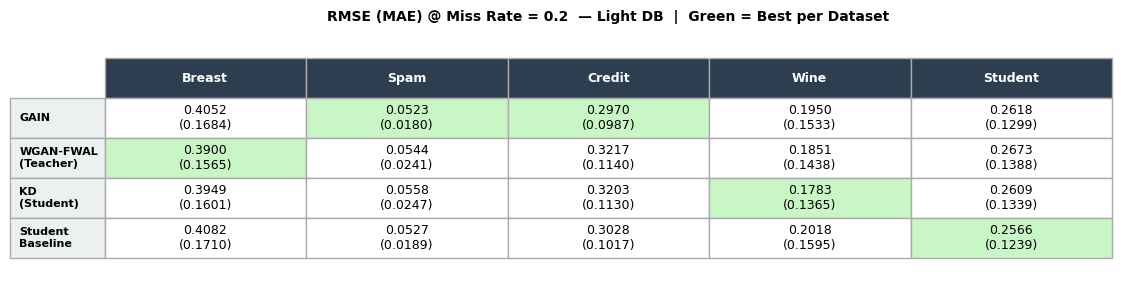

[저장] ./results/table_main_miss02.png


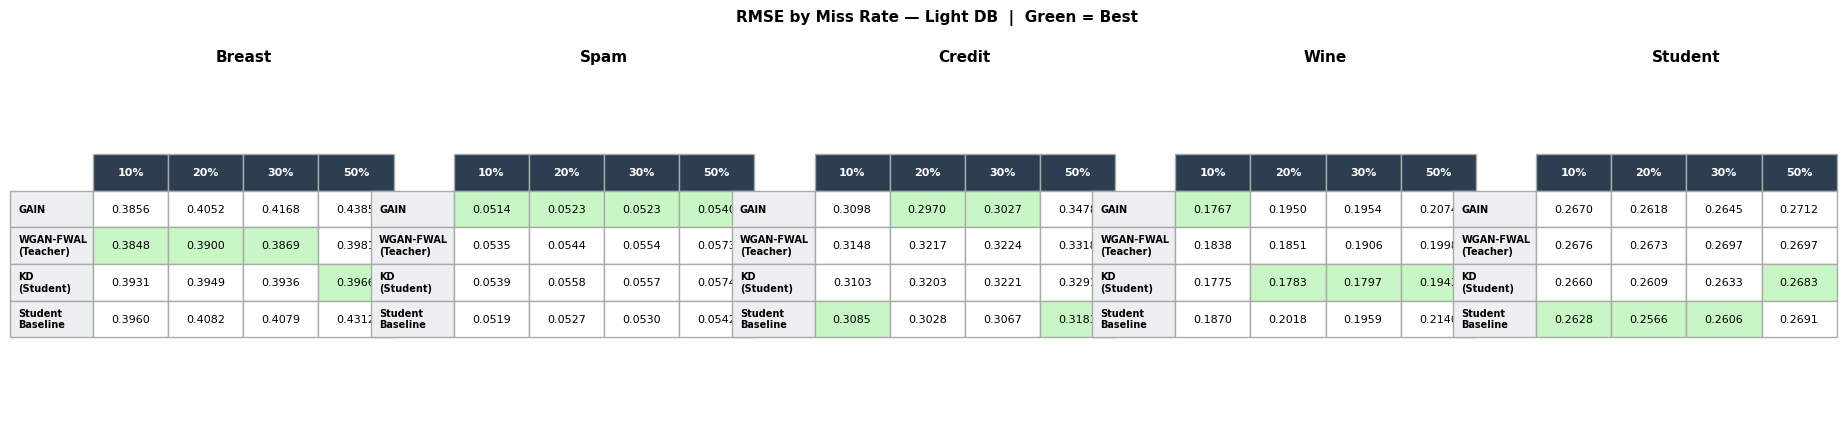

[저장] ./results/table_rmse_by_missrate.png

저장 완료: /root/GAIN/results/


In [19]:
# ════════════════════════════════════════════════════════
# 결과 테이블 이미지 저장 (논문용 깔끔한 표)
# ════════════════════════════════════════════════════════
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ── CSV 자동 로드 (가장 최신 파일) ───────────────────────
RESULTS_DIR = os.path.join('.', 'results')
csv_files   = sorted(glob.glob(os.path.join(RESULTS_DIR, 'light_results_*.csv')))
if not csv_files:
    print("❌ light_results_*.csv 파일 없음 — 저장 셀 먼저 실행하세요")
else:
    df = pd.read_csv(csv_files[-1])
    df['rmse'] = df['rmse'].round(4)
    df['mae']  = df['mae'].round(4)

    MODEL_ORDER = ['GAIN', 'WGAN_FWAL', 'KD', 'Student_Baseline']
    MODEL_LABEL = {'GAIN': 'GAIN', 'WGAN_FWAL': 'WGAN-FWAL\n(Teacher)',
                   'KD': 'KD\n(Student)', 'Student_Baseline': 'Student\nBaseline'}
    DS_ORDER    = ['breast_cancer', 'spam', 'credit', 'wine', 'student']
    DS_LABEL    = {'breast_cancer': 'Breast', 'spam': 'Spam',
                   'credit': 'Credit', 'wine': 'Wine', 'student': 'Student'}
    MR_ORDER    = [0.1, 0.2, 0.3, 0.5]   # 0.05 제외 (너무 쉬운 케이스)

    # ── Figure 1: miss_rate=0.2 메인 비교 표 ─────────────
    sub02 = df[df['Miss_Rate'] == 0.2].copy()
    pivot_rmse = sub02.pivot_table(values='rmse', index='Model', columns='Dataset')
    pivot_mae  = sub02.pivot_table(values='mae',  index='Model', columns='Dataset')
    pivot_rmse = pivot_rmse.reindex(MODEL_ORDER)[DS_ORDER]
    pivot_mae  = pivot_mae.reindex(MODEL_ORDER)[DS_ORDER]

    fig, ax = plt.subplots(figsize=(13, 3.2))
    ax.axis('off')

    col_labels = [DS_LABEL[d] for d in DS_ORDER]
    row_labels = [MODEL_LABEL[m] for m in MODEL_ORDER]

    # 셀 값: RMSE / MAE 두 줄
    cell_text = []
    for m in MODEL_ORDER:
        row = []
        for d in DS_ORDER:
            r = pivot_rmse.loc[m, d] if m in pivot_rmse.index else float('nan')
            a = pivot_mae.loc[m, d]  if m in pivot_mae.index  else float('nan')
            row.append(f'{r:.4f}\n({a:.4f})')
        cell_text.append(row)

    # 열별 최솟값(RMSE 기준) 찾아서 색 지정
    cell_colors = [['white']*len(DS_ORDER) for _ in MODEL_ORDER]
    for j, d in enumerate(DS_ORDER):
        col_vals = [pivot_rmse.loc[m, d] for m in MODEL_ORDER]
        min_idx  = int(np.nanargmin(col_vals))
        cell_colors[min_idx][j] = '#c8f7c5'   # 초록색 하이라이트

    tbl = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellColours=cell_colors,
        cellLoc='center',
        loc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.0, 2.4)

    # 헤더 스타일
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor('#aaaaaa')
        if r == 0:
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')
        if c == -1:
            cell.set_facecolor('#ecf0f1')
            cell.set_text_props(fontweight='bold', fontsize=8)

    plt.title('RMSE (MAE) @ Miss Rate = 0.2  — Light DB  |  Green = Best per Dataset',
              fontsize=10, fontweight='bold', pad=10)
    img1 = os.path.join(RESULTS_DIR, 'table_main_miss02.png')
    plt.savefig(img1, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"[저장] {img1}")

    # ── Figure 2: 데이터셋별 miss rate 변화 RMSE 표 ──────
    nds  = len(DS_ORDER)
    nmr  = len(MR_ORDER)
    fig2, axes2 = plt.subplots(1, nds, figsize=(4.5*nds, 4.5))
    if nds == 1: axes2 = [axes2]

    for ax2, ds in zip(axes2, DS_ORDER):
        ax2.axis('off')
        sub_ds = df[(df['Dataset'] == ds) & (df['Miss_Rate'].isin(MR_ORDER))].copy()
        pivot  = sub_ds.pivot_table(values='rmse', index='Model', columns='Miss_Rate')
        pivot  = pivot.reindex(MODEL_ORDER)[[float(m) for m in MR_ORDER]]

        cell_t = [[f'{pivot.loc[m, float(mr)]:.4f}' if m in pivot.index else '-'
                   for mr in MR_ORDER] for m in MODEL_ORDER]
        cell_c = [['white']*nmr for _ in MODEL_ORDER]
        for j, mr in enumerate(MR_ORDER):
            col_v  = [pivot.loc[m, float(mr)] for m in MODEL_ORDER]
            min_i  = int(np.nanargmin(col_v))
            cell_c[min_i][j] = '#c8f7c5'

        tbl2 = ax2.table(
            cellText=cell_t,
            rowLabels=[MODEL_LABEL[m] for m in MODEL_ORDER],
            colLabels=[f'{int(mr*100)}%' for mr in MR_ORDER],
            cellColours=cell_c,
            cellLoc='center',
            loc='center'
        )
        tbl2.auto_set_font_size(False)
        tbl2.set_fontsize(8)
        tbl2.scale(1.0, 2.2)
        for (r, c), cell in tbl2.get_celld().items():
            cell.set_edgecolor('#aaaaaa')
            if r == 0:
                cell.set_facecolor('#2c3e50')
                cell.set_text_props(color='white', fontweight='bold', fontsize=8)
            if c == -1:
                cell.set_facecolor('#ecf0f1')
                cell.set_text_props(fontweight='bold', fontsize=7)
        ax2.set_title(DS_LABEL[ds], fontsize=11, fontweight='bold', pad=8)

    fig2.suptitle('RMSE by Miss Rate — Light DB  |  Green = Best',
                  fontsize=11, fontweight='bold', y=1.02)
    img2 = os.path.join(RESULTS_DIR, 'table_rmse_by_missrate.png')
    fig2.savefig(img2, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"[저장] {img2}")
    print(f"\n저장 완료: {os.path.abspath(RESULTS_DIR)}/")


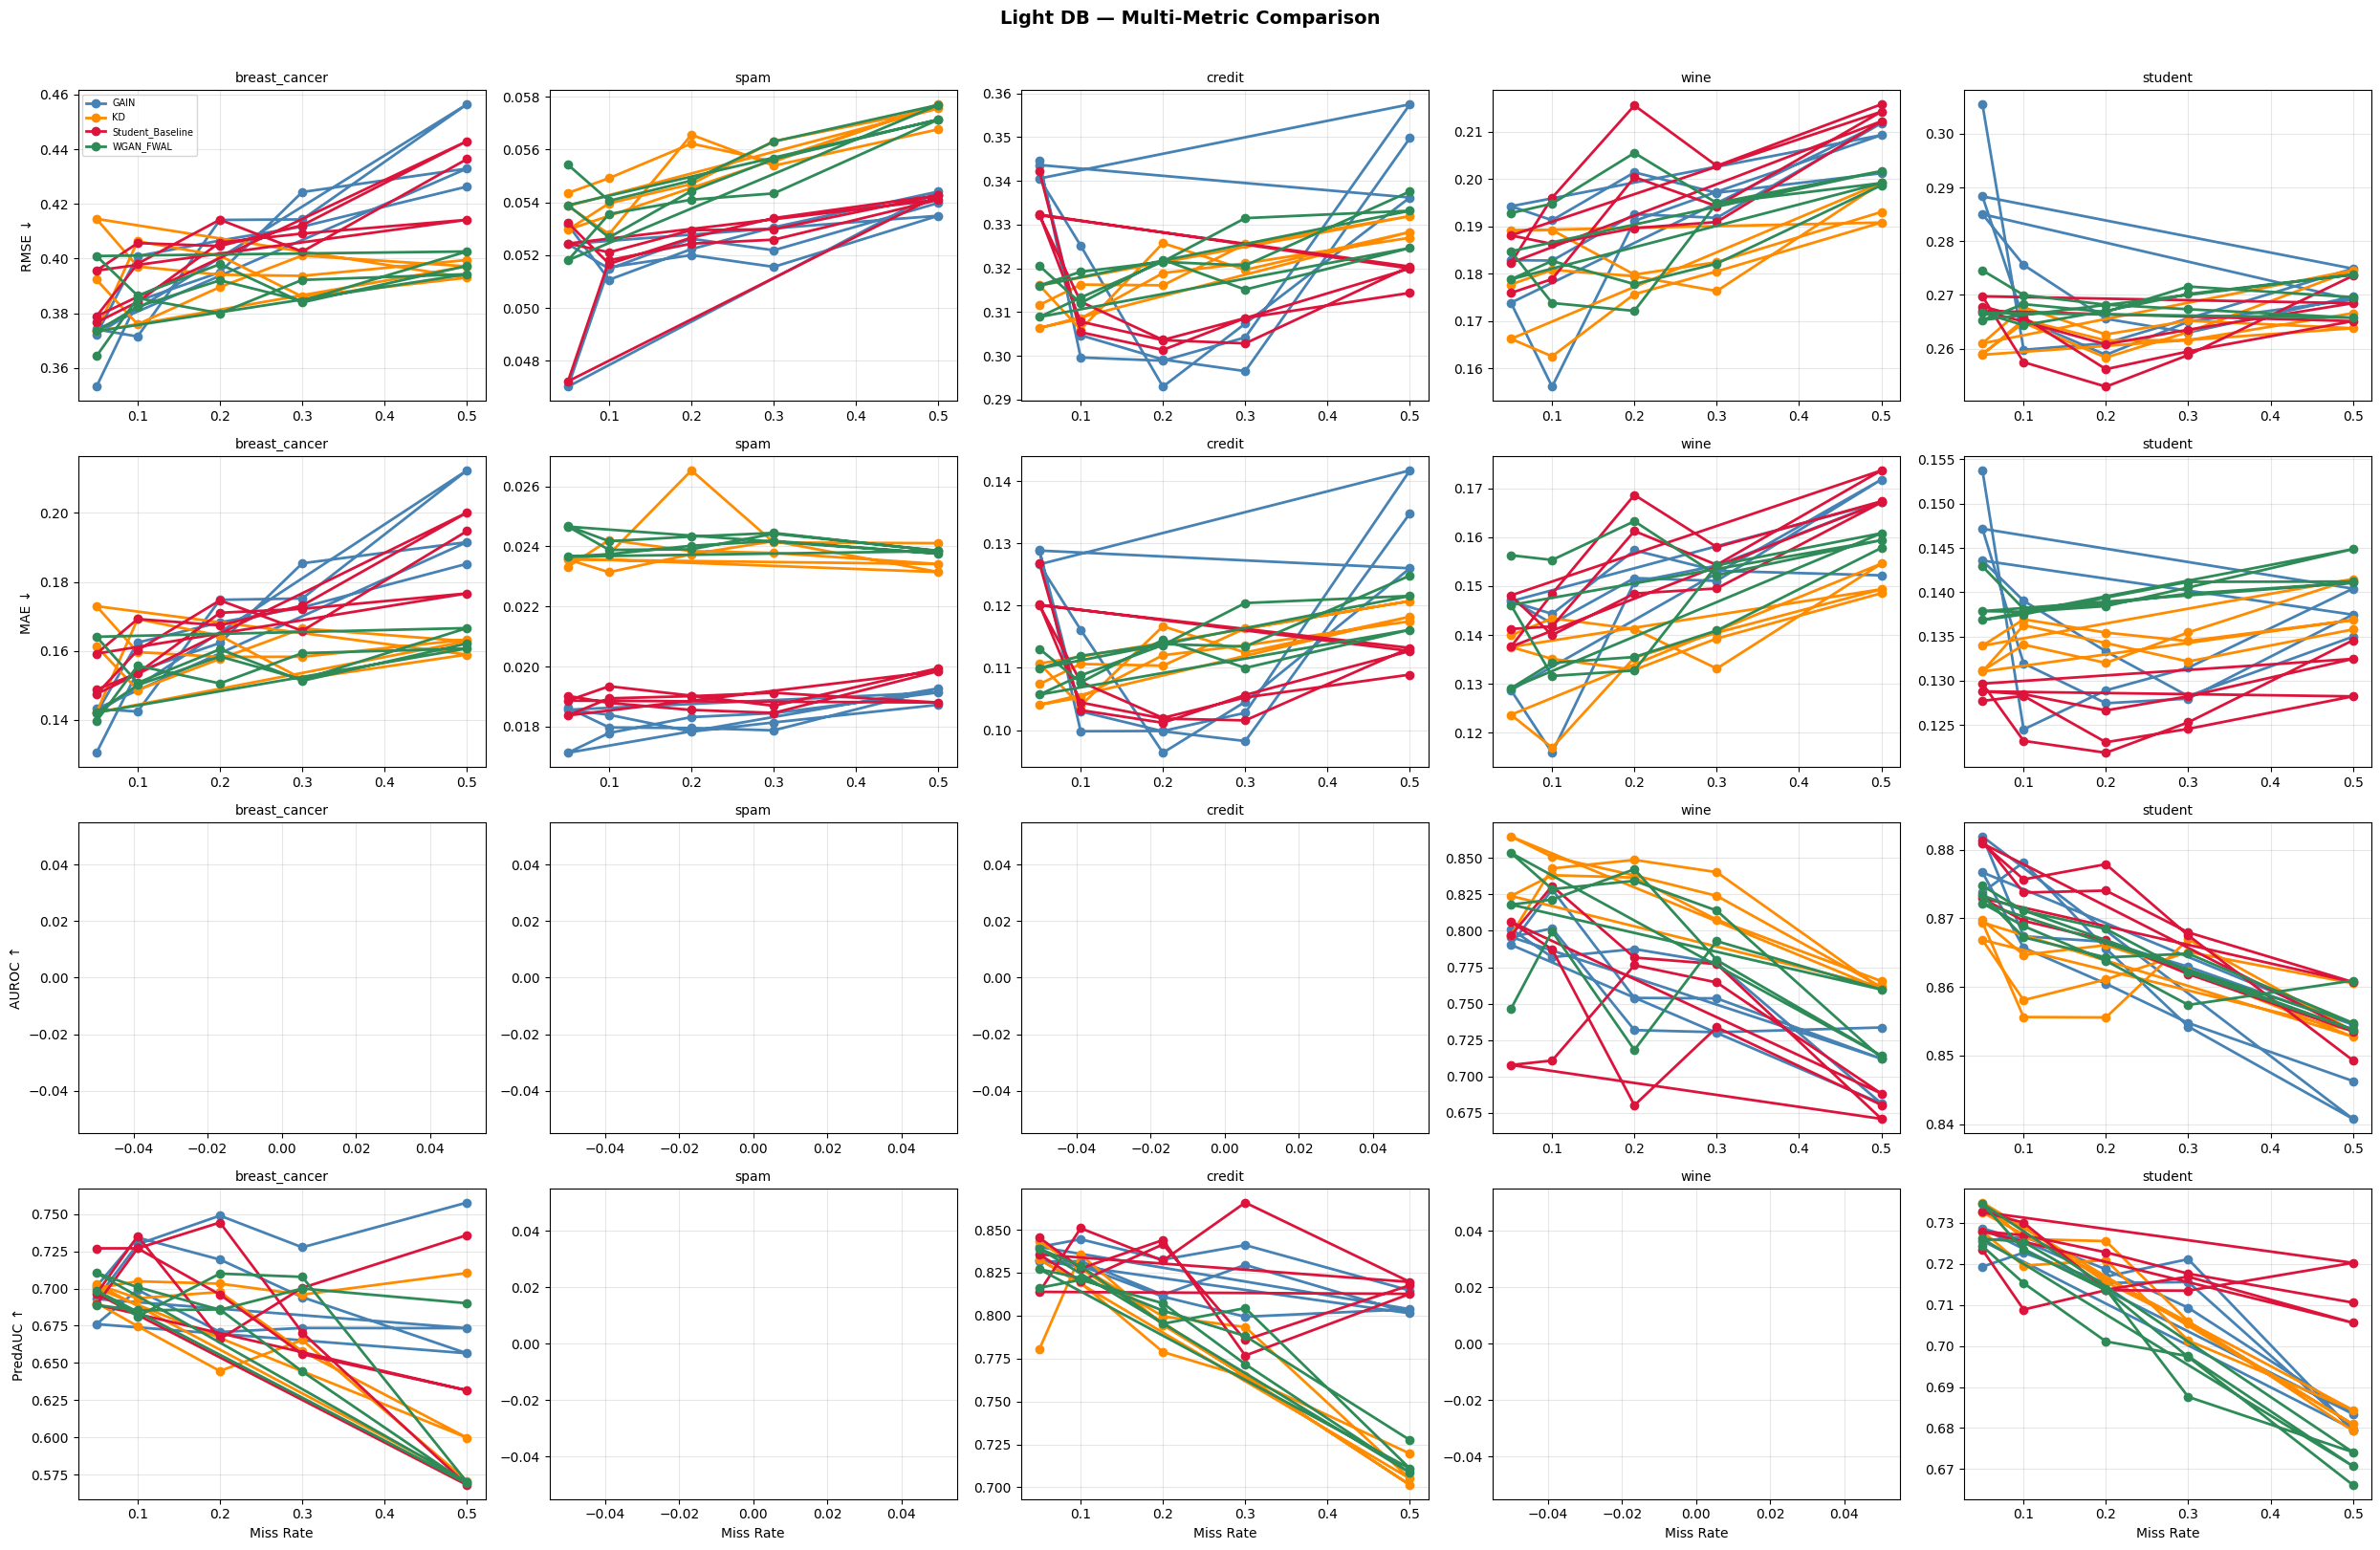

In [20]:
# ── Light DB: 모델 × 결측률 × 지표 시각화 ──────────────────
METRICS_TO_PLOT = ['rmse', 'mae', 'auroc', 'pred_auc']
METRIC_LABELS   = {'rmse':'RMSE ↓','mae':'MAE ↓','auroc':'AUROC ↑','pred_auc':'PredAUC ↑'}
COLORS = {'GAIN':'steelblue', 'WGAN_FWAL':'seagreen',
          'KD':'darkorange', 'Student_Baseline':'crimson'}

fig, axes = plt.subplots(len(METRICS_TO_PLOT), len(DATASETS),
                         figsize=(5*len(DATASETS), 4*len(METRICS_TO_PLOT)))

for row_i, metric in enumerate(METRICS_TO_PLOT):
    for col_j, ds in enumerate(DATASETS):
        ax  = axes[row_i][col_j]
        sub = summary_df[summary_df['Dataset'] == ds]
        for mname, grp in sub.groupby('Model'):
            ax.plot(grp['Miss_Rate'], grp[metric], marker='o',
                    label=mname, color=COLORS.get(mname), linewidth=2)
        ax.set_title(f'{ds}', fontsize=10)
        ax.set_xlabel('Miss Rate' if row_i == len(METRICS_TO_PLOT)-1 else '')
        ax.set_ylabel(METRIC_LABELS[metric] if col_j == 0 else '')
        if row_i == 0 and col_j == 0:
            ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

plt.suptitle('Light DB — Multi-Metric Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


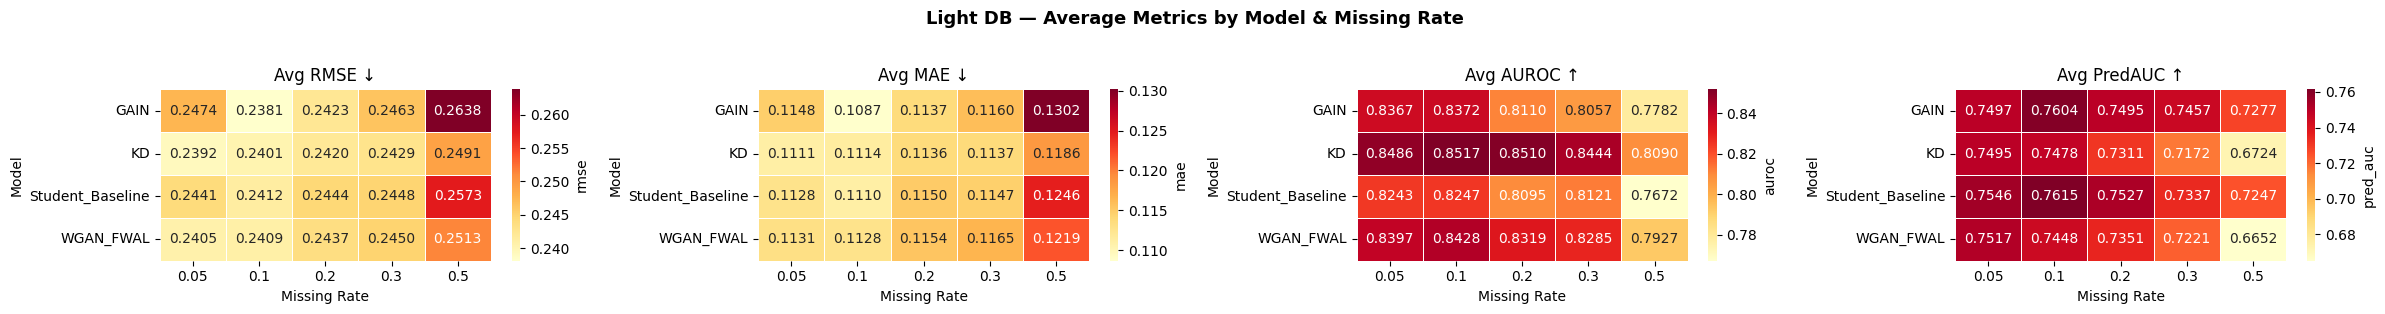


[Heavy DB Results]

── RMSE ↓ ──
Model                GAIN      KD  WGAN_FWAL
Dataset Miss_Rate                           
CRITEO  0.1        0.0296  0.0339     0.0417
        0.2        0.0299  0.0394     0.0324
        0.3        0.0305  0.0348     0.0333
HIGGS   0.1        0.2401  0.2612     0.3173
        0.2        0.2390  0.2572     0.2868
        0.3        0.2394  0.2553     0.2888

── MAE ↓ ──
Model                GAIN      KD  WGAN_FWAL
Dataset Miss_Rate                           
CRITEO  0.1        0.0118  0.0131     0.0159
        0.2        0.0114  0.0127     0.0129
        0.3        0.0116  0.0122     0.0133
HIGGS   0.1        0.1618  0.1599     0.1850
        0.2        0.1605  0.1618     0.1704
        0.3        0.1603  0.1586     0.1701

── AUROC ↑ ──
Model                GAIN      KD  WGAN_FWAL
Dataset Miss_Rate                           
CRITEO  0.1        0.6987  0.6451     0.6419
        0.2        0.6228  0.6793     0.6565
        0.3        0.6307  0.5782     

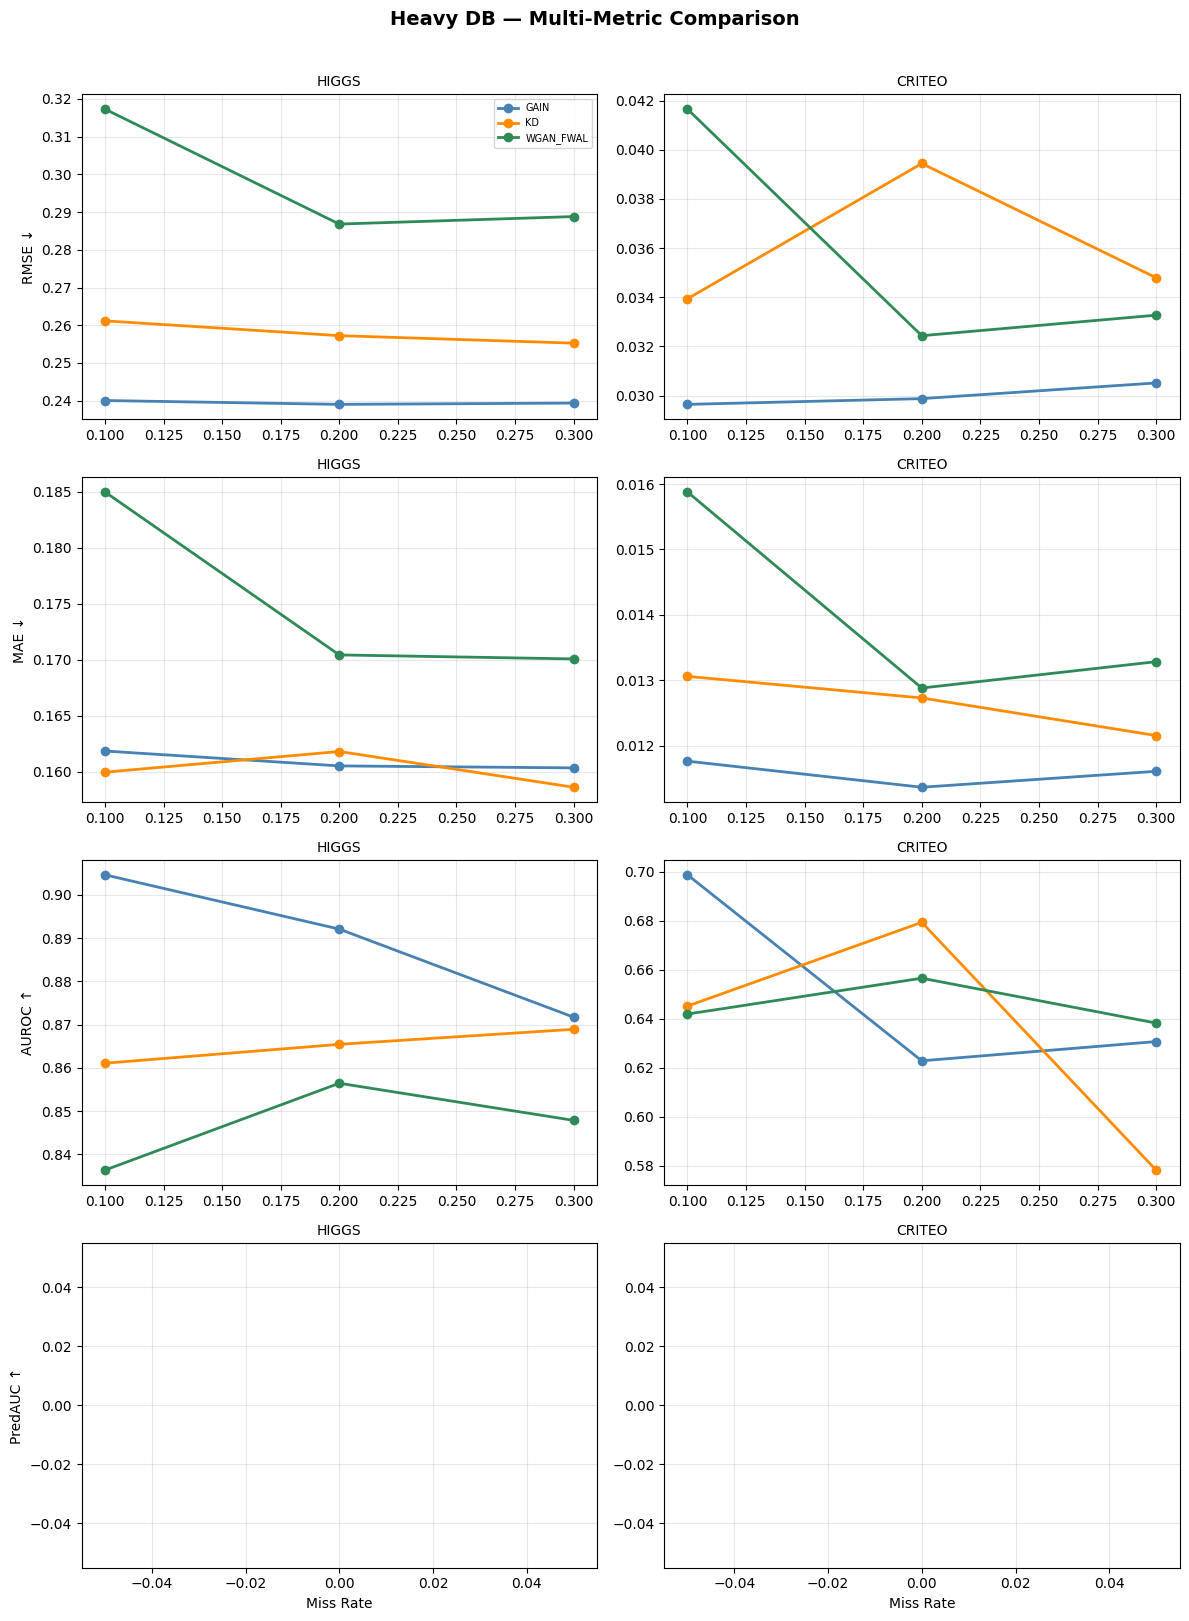

In [21]:
# ── 결측률별 평균 지표 히트맵 (Light DB) ──────────────────
fig, axes = plt.subplots(1, len(METRICS_TO_PLOT), figsize=(6*len(METRICS_TO_PLOT), 3))
for ax, metric in zip(axes, METRICS_TO_PLOT):
    pivot = summary_df.groupby(['Model','Miss_Rate'])[metric].mean().unstack()
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': metric})
    ax.set_title(f'Avg {METRIC_LABELS[metric]}')
    ax.set_xlabel('Missing Rate'); ax.set_ylabel('Model')
plt.suptitle('Light DB — Average Metrics by Model & Missing Rate',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# ── Heavy DB 결과 테이블 출력 ──────────────────────────────
if results_heavy:
    heavy_df = pd.DataFrame(results_heavy)
    print('\n[Heavy DB Results]')
    for metric in METRICS_TO_PLOT:
        print(f'\n── {METRIC_LABELS[metric]} ──')
        pivot_h = heavy_df.pivot_table(
            index=['Dataset','Miss_Rate'], columns='Model', values=metric
        ).round(4)
        print(pivot_h)

    # Heavy DB 라인 차트
    heavy_ds_list = heavy_df['Dataset'].unique().tolist()
    fig, axes = plt.subplots(len(METRICS_TO_PLOT), len(heavy_ds_list),
                             figsize=(6*len(heavy_ds_list), 4*len(METRICS_TO_PLOT)),
                             squeeze=False)
    for row_i, metric in enumerate(METRICS_TO_PLOT):
        for col_j, ds in enumerate(heavy_ds_list):
            ax  = axes[row_i][col_j]
            sub = heavy_df[heavy_df['Dataset'] == ds]
            for mname, grp in sub.groupby('Model'):
                ax.plot(grp['Miss_Rate'], grp[metric], marker='o',
                        label=mname, color=COLORS.get(mname), linewidth=2)
            ax.set_title(f'{ds}', fontsize=10)
            ax.set_xlabel('Miss Rate' if row_i == len(METRICS_TO_PLOT)-1 else '')
            ax.set_ylabel(METRIC_LABELS[metric] if col_j == 0 else '')
            if row_i == 0 and col_j == 0:
                ax.legend(fontsize=7)
            ax.grid(alpha=0.3)
    plt.suptitle('Heavy DB — Multi-Metric Comparison', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Heavy DB 결과 없음 (파일 미존재 또는 건너뜀).')


---
## 12. 고급 평가 — FLOPs / Latency / FID / Diversity


  [LIGHT DB] 고급 평가 시작

  [HEAVY DB] 고급 평가 시작

────────────────────────────────────────────────────────────
  [HEAVY] higgs | miss=0.1
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────────
  Metric                                    GAIN         WGAN_FWAL                KD
────────────────────────────────────────────────────────────────────────────────────
  Parameters                               3,220             3,220             1,660
  FLOPs (approx)                           6,272             6,272             3,200
  Latency mean (ms)                        0.373             0.368             0.353
  Latency std (ms)                         0.013             0.012             0.014
  Diversity (bins ↓)                           1                 1                 1
  Final FID ↓                                N/A               N/A               N/A
───────────────────────────────────────

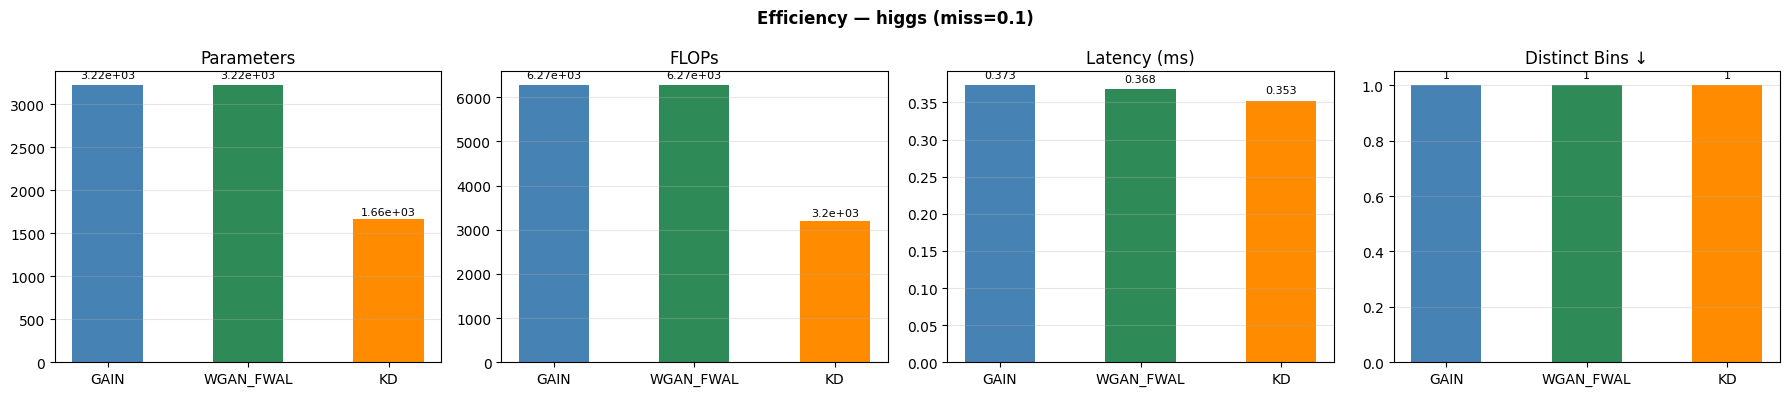


────────────────────────────────────────────────────────────
  [HEAVY] higgs | miss=0.2
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────────
  Metric                                    GAIN         WGAN_FWAL                KD
────────────────────────────────────────────────────────────────────────────────────
  Parameters                               3,220             3,220             1,660
  FLOPs (approx)                           6,272             6,272             3,200
  Latency mean (ms)                        0.378             0.370             0.361
  Latency std (ms)                         0.014             0.015             0.015
  Diversity (bins ↓)                           1                 1                 1
  Final FID ↓                                N/A               N/A               N/A
────────────────────────────────────────────────────────────────────────────────────


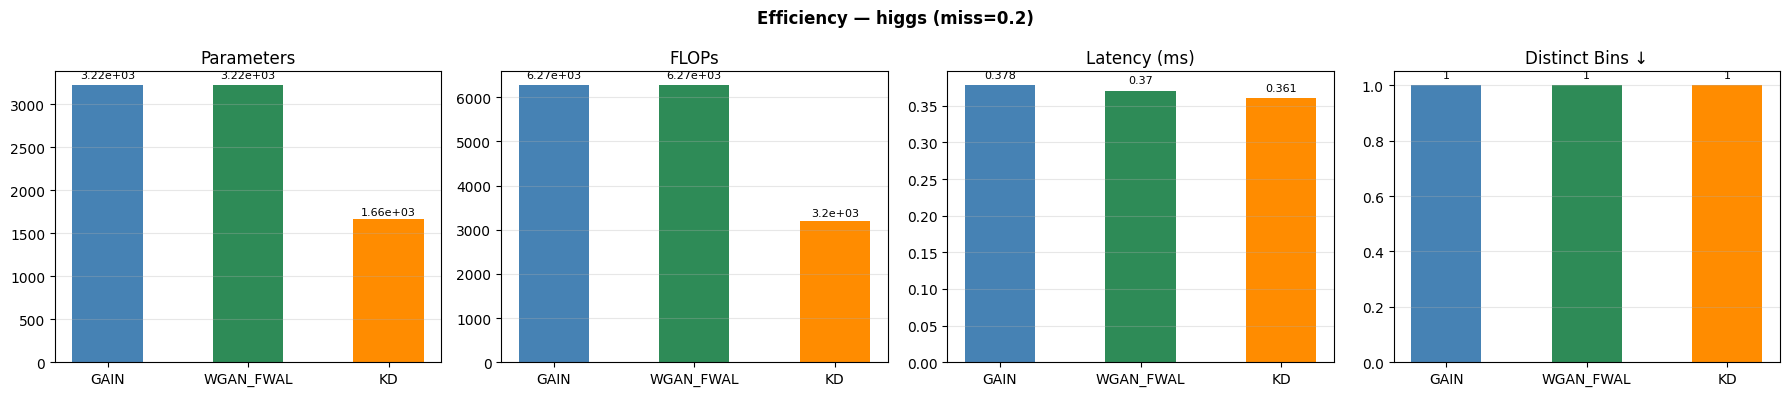


────────────────────────────────────────────────────────────
  [HEAVY] higgs | miss=0.3
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────────
  Metric                                    GAIN         WGAN_FWAL                KD
────────────────────────────────────────────────────────────────────────────────────
  Parameters                               3,220             3,220             1,660
  FLOPs (approx)                           6,272             6,272             3,200
  Latency mean (ms)                        0.375             0.368             0.354
  Latency std (ms)                         0.012             0.016             0.015
  Diversity (bins ↓)                           1                 1                 1
  Final FID ↓                                N/A               N/A               N/A
────────────────────────────────────────────────────────────────────────────────────


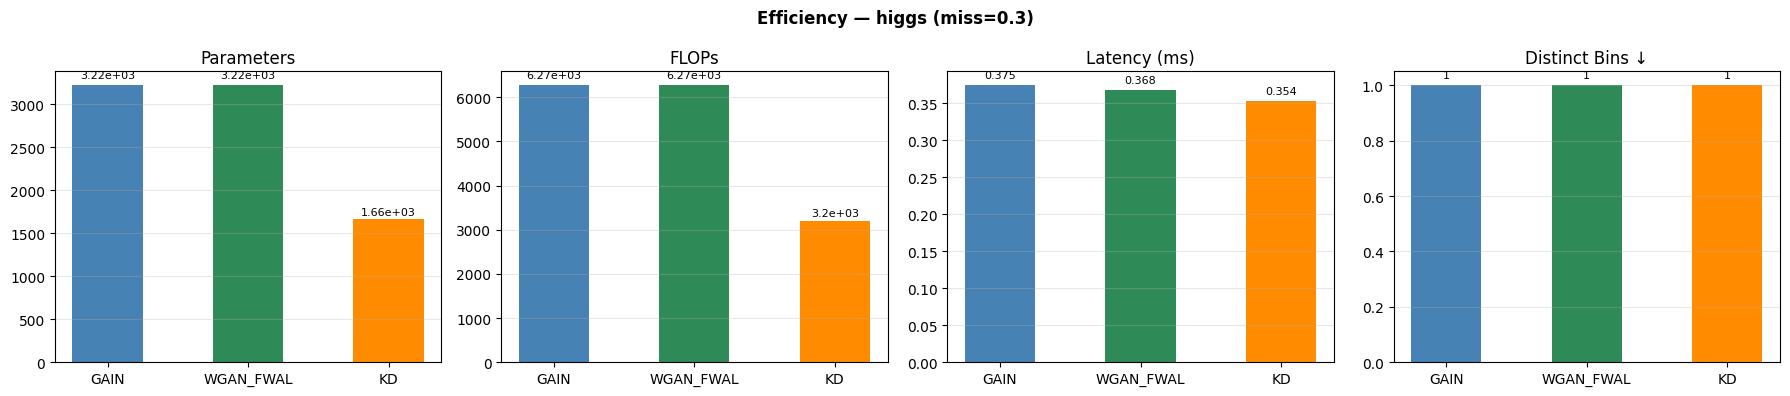


────────────────────────────────────────────────────────────
  [HEAVY] criteo | miss=0.1
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────────
  Metric                                    GAIN         WGAN_FWAL                KD
────────────────────────────────────────────────────────────────────────────────────
  Parameters                                 715               715               925
  FLOPs (approx)                           1,352             1,352             1,760
  Latency mean (ms)                        0.372             0.370             0.396
  Latency std (ms)                         0.018             0.013             0.038
  Diversity (bins ↓)                           1                 1                 1
  Final FID ↓                                N/A               N/A               N/A
────────────────────────────────────────────────────────────────────────────────────

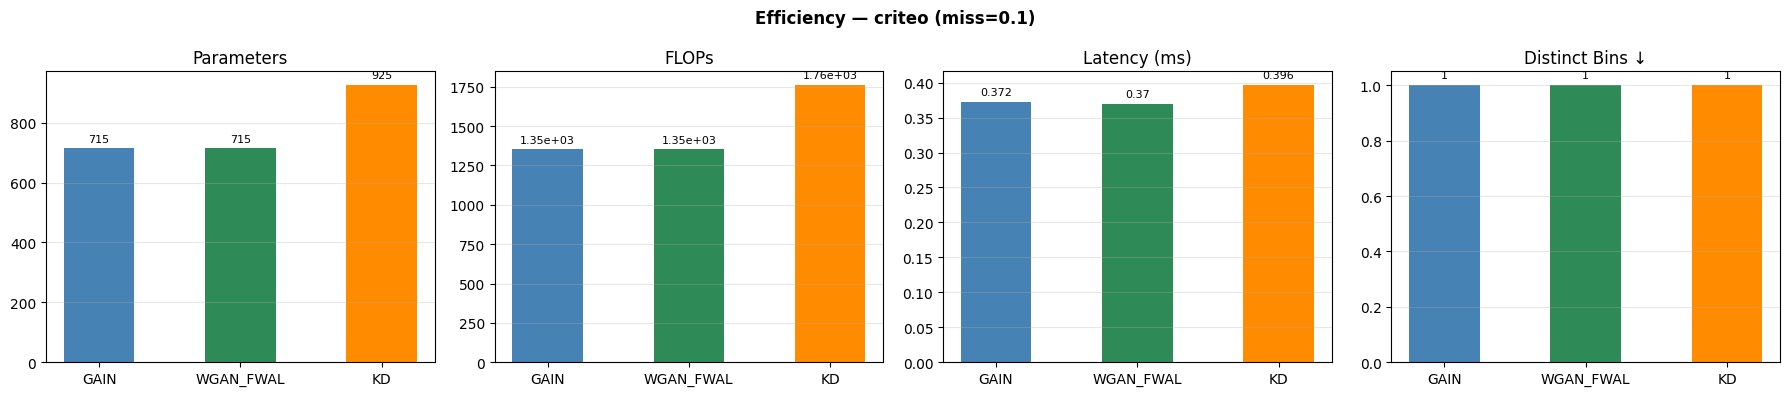


────────────────────────────────────────────────────────────
  [HEAVY] criteo | miss=0.2
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────────
  Metric                                    GAIN         WGAN_FWAL                KD
────────────────────────────────────────────────────────────────────────────────────
  Parameters                                 715               715               925
  FLOPs (approx)                           1,352             1,352             1,760
  Latency mean (ms)                        0.444             0.445             0.420
  Latency std (ms)                         0.017             0.014             0.015
  Diversity (bins ↓)                           1                 1                 1
  Final FID ↓                                N/A               N/A               N/A
────────────────────────────────────────────────────────────────────────────────────

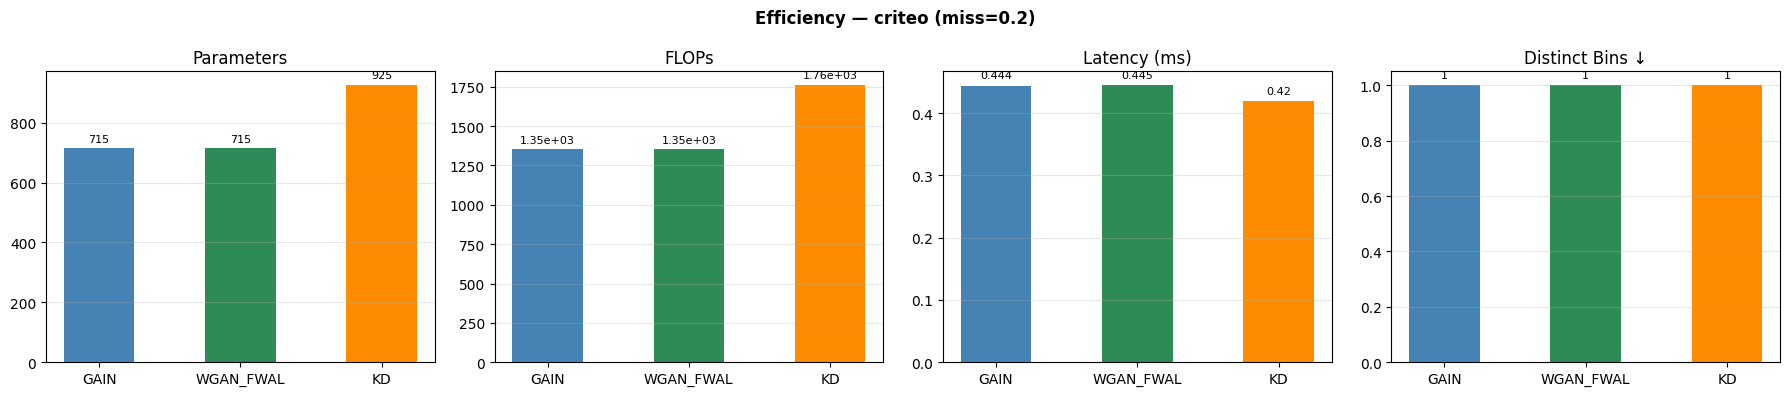


────────────────────────────────────────────────────────────
  [HEAVY] criteo | miss=0.3
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────────
  Metric                                    GAIN         WGAN_FWAL                KD
────────────────────────────────────────────────────────────────────────────────────
  Parameters                                 715               715               925
  FLOPs (approx)                           1,352             1,352             1,760
  Latency mean (ms)                        0.367             0.361             0.345
  Latency std (ms)                         0.017             0.014             0.010
  Diversity (bins ↓)                           1                 1                 1
  Final FID ↓                                N/A               N/A               N/A
────────────────────────────────────────────────────────────────────────────────────

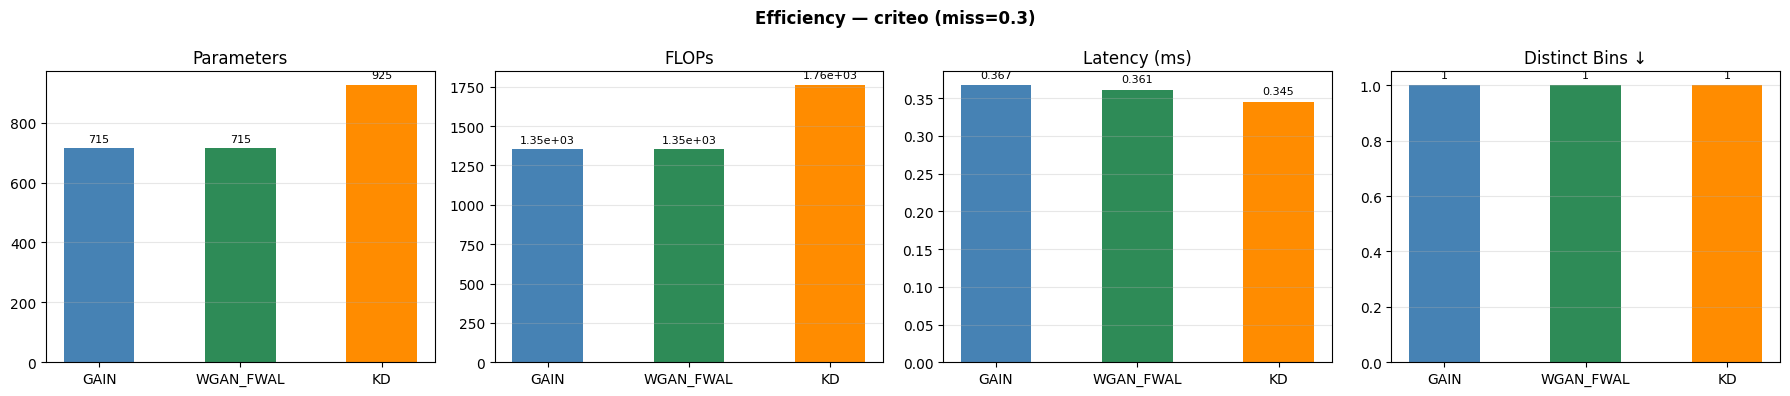



  [고급 평가 전체 요약]
db_type dataset  miss_rate     model  params  flops  latency  diversity fid_final
  heavy   higgs        0.1      GAIN    3220   6272 0.373244          1      None
  heavy   higgs        0.1 WGAN_FWAL    3220   6272 0.367937          1      None
  heavy   higgs        0.1        KD    1660   3200 0.352568          1      None
  heavy   higgs        0.2      GAIN    3220   6272 0.378069          1      None
  heavy   higgs        0.2 WGAN_FWAL    3220   6272 0.370395          1      None
  heavy   higgs        0.2        KD    1660   3200 0.360560          1      None
  heavy   higgs        0.3      GAIN    3220   6272 0.374595          1      None
  heavy   higgs        0.3 WGAN_FWAL    3220   6272 0.368065          1      None
  heavy   higgs        0.3        KD    1660   3200 0.353525          1      None
  heavy  criteo        0.1      GAIN     715   1352 0.371641          1      None
  heavy  criteo        0.1 WGAN_FWAL     715   1352 0.369598          1      Non

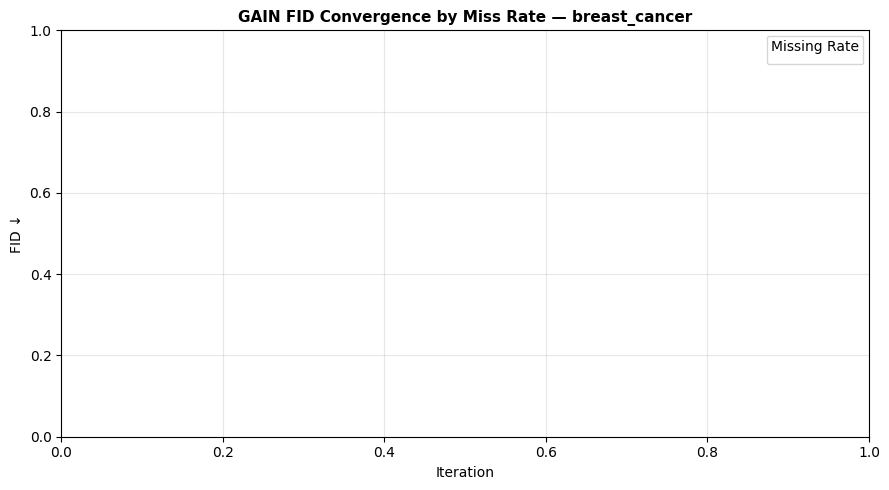

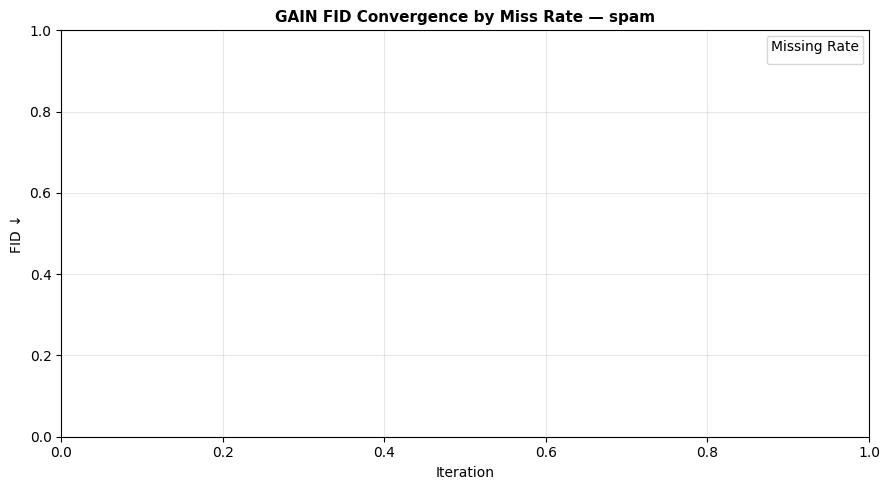

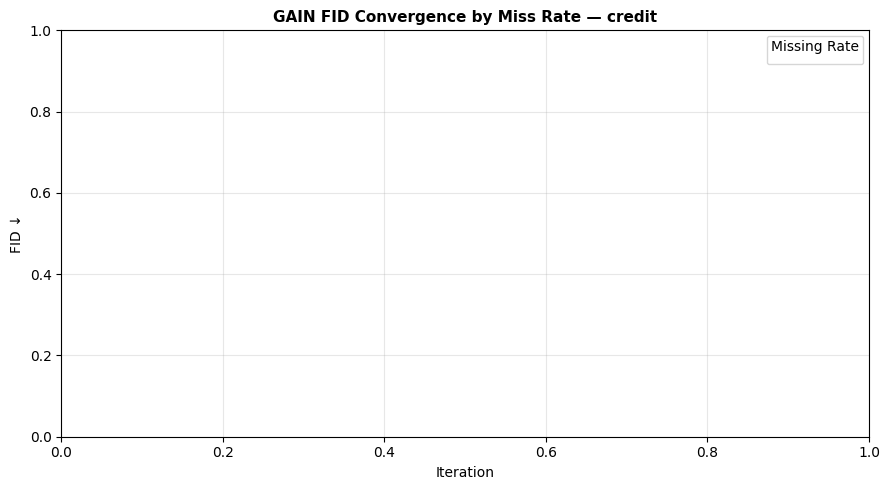

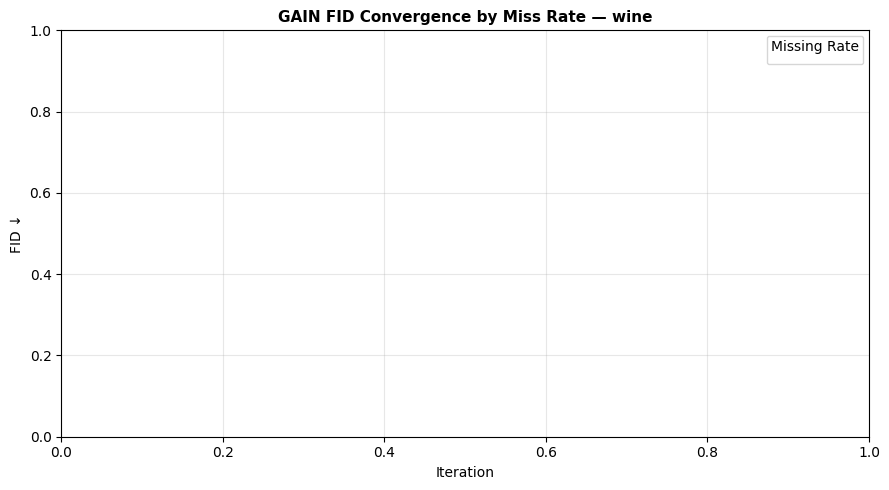

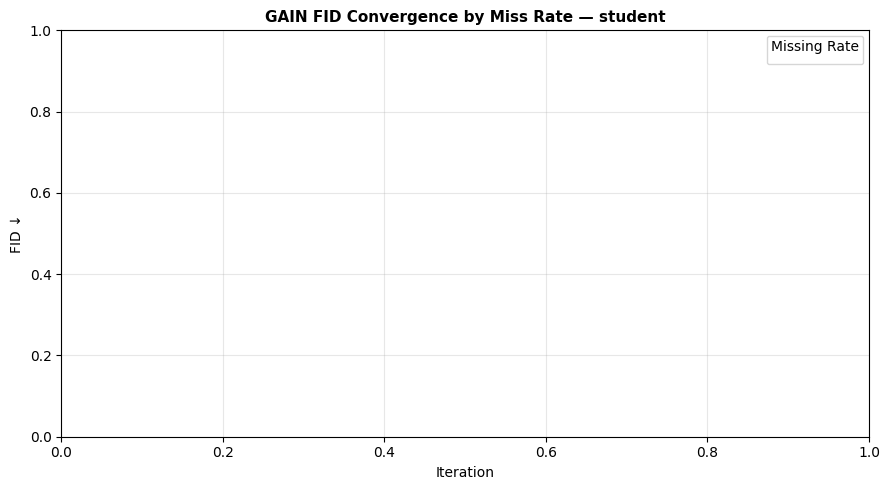


[FID] Light DB — 최종 FID 히트맵 (데이터셋 × 결측률)


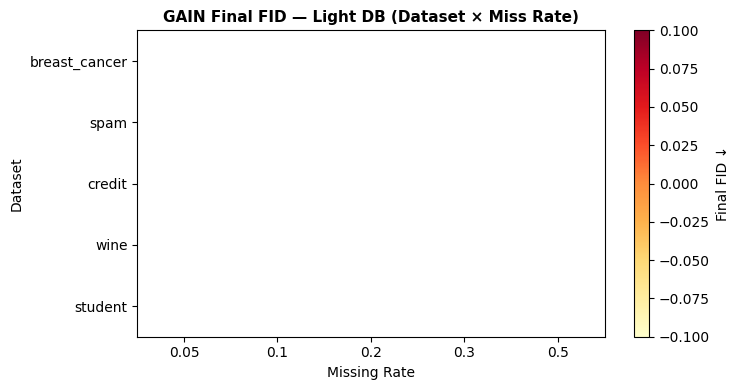


[FID] Heavy DB — 최종 FID 히트맵


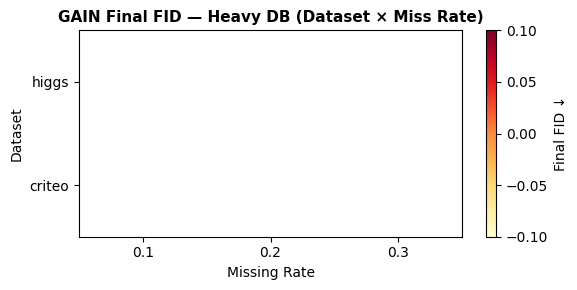


결과 이미지 저장 경로: /root/GAIN/adv_eval_results


In [22]:
# ════════════════════════════════════════════════════════
# 12. 고급 평가 — Light & Heavy 전체 조합 일괄 수행
# ════════════════════════════════════════════════════════

ADV_SAVE_DIR = './adv_eval_results'
device_adv   = torch.device(str(DEVICE))

all_adv_records = []   # 전체 결과를 DataFrame으로 저장용

def run_one_adv_eval(db_type, ds_name, miss_rate, slot):
    """
    slot = trained_G_all[db_type][ds_name][miss_rate]
    고급 지표를 계산하고 딕셔너리로 반환.
    """
    ori      = slot['_ori']
    mask     = slot['_mask']
    norm_x   = slot['_norm_x']
    norm_p   = slot['_norm_p']
    imp_dict = slot['_imp']
    fid_h    = fid_hist_all [db_type][ds_name][miss_rate]
    grad_h   = grad_hist_all[db_type][ds_name][miss_rate]

    label  = f'[{db_type.upper()}] {ds_name} | miss={miss_rate}'
    print(f'\n{"─"*60}')
    print(f'  {label}')
    print(f'{"─"*60}')

    summary = {}
    for mname, G in slot.items():
        if mname.startswith('_'):
            continue
        imp = imp_dict.get(mname)
        if imp is None:
            continue

        norm_imp, _ = normalization(imp, norm_p)
        lat_mean, lat_std = measure_latency(G, norm_x, mask, device_adv, runs=20)
        div_score         = diversity_score(ori, imp, mask)

        summary[mname] = {
            'db_type'  : db_type,
            'dataset'  : ds_name,
            'miss_rate': miss_rate,
            'model'    : mname,
            'params'   : count_parameters(G),
            'flops'    : count_flops(G),
            'latency'  : lat_mean,
            'lat_std'  : lat_std,
            'diversity': div_score,
            'fid_final': fid_h[mname][-1] if fid_h.get(mname) else None,
        }

    # 텍스트 테이블
    model_names = list(summary.keys())
    header = f"  {'Metric':28s}" + ''.join(f'{m:>18s}' for m in model_names)
    sep    = '─' * len(header)
    print(sep); print(header); print(sep)
    for key, label_str in [
        ('params',    'Parameters'),
        ('flops',     'FLOPs (approx)'),
        ('latency',   'Latency mean (ms)'),
        ('lat_std',   'Latency std (ms)'),
        ('diversity', 'Diversity (bins ↓)'),
        ('fid_final', 'Final FID ↓'),
    ]:
        row = f'  {label_str:28s}'
        for m in model_names:
            val = summary[m][key]
            row += f'{val:>18.3f}' if isinstance(val, float) else \
                   f'{val:>18,}'   if isinstance(val, int)   else f"{'N/A':>18s}"
        print(row)
    print(sep)

    # 시각화 저장
    save_dir = os.path.join(ADV_SAVE_DIR, db_type, ds_name, str(miss_rate))
    os.makedirs(save_dir, exist_ok=True)

    plot_efficiency_bars(
        {m: {k: summary[m][k] for k in ('params','flops','latency','diversity')}
         for m in model_names},
        title=f'Efficiency — {ds_name} (miss={miss_rate})',
        save_path=os.path.join(save_dir, 'efficiency_bars.png')
    )

    if fid_h.get('GAIN'):
        plot_fid_convergence_single(
            fid_h['GAIN'],
            title=f'GAIN FID Convergence — {ds_name} (miss={miss_rate})',
            save_path=os.path.join(save_dir, 'fid_convergence.png')
        )

    return list(summary.values())


# ── Light DB 전체 순회 ──────────────────────────────────
print('\n' + '='*60)
print('  [LIGHT DB] 고급 평가 시작')
print('='*60)
for ds in DATASETS:
    for mr in MISS_RATES:
        if ds in trained_G_all['light'] and mr in trained_G_all['light'][ds]:
            records = run_one_adv_eval('light', ds, mr,
                                       trained_G_all['light'][ds][mr])
            all_adv_records.extend(records)

# ── Heavy DB 전체 순회 ─────────────────────────────────
print('\n' + '='*60)
print('  [HEAVY DB] 고급 평가 시작')
print('='*60)
for ds_name in trained_G_all['heavy']:
    for mr in HEAVY_MISS_RATES:
        if mr in trained_G_all['heavy'][ds_name]:
            records = run_one_adv_eval('heavy', ds_name, mr,
                                       trained_G_all['heavy'][ds_name][mr])
            all_adv_records.extend(records)

# ── 통합 요약 DataFrame ────────────────────────────────
adv_df = pd.DataFrame(all_adv_records)
print('\n\n' + '='*60)
print('  [고급 평가 전체 요약]')
print('='*60)
print(adv_df[['db_type','dataset','miss_rate','model',
              'params','flops','latency','diversity','fid_final']]
      .to_string(index=False))

# ── FID 통합 시각화 ────────────────────────────────────

# Light DB: 데이터셋별 결측률 FID 수렴 곡선
print('\n[FID] Light DB — 데이터셋별 결측률 FID 수렴 곡선')
for ds in DATASETS:
    if ds not in fid_hist_all['light']:
        continue
    fid_by_mr = {
        mr: fid_hist_all['light'][ds][mr].get('GAIN', [])
        for mr in MISS_RATES
        if mr in fid_hist_all['light'][ds]
    }
    plot_fid_by_miss_rate(
        fid_by_mr,
        miss_rates=MISS_RATES,
        title=f'GAIN FID Convergence by Miss Rate — {ds}',
        save_path=os.path.join(ADV_SAVE_DIR, 'light', ds, 'fid_by_miss_rate.png')
    )

# Light DB: 최종 FID 히트맵
print('\n[FID] Light DB — 최종 FID 히트맵 (데이터셋 × 결측률)')
fid_final_light = {}
for ds in DATASETS:
    fid_final_light[ds] = {}
    for mr in MISS_RATES:
        hist = fid_hist_all.get('light', {}).get(ds, {}).get(mr, {}).get('GAIN', [])
        fid_final_light[ds][mr] = hist[-1] if hist else None

plot_fid_final_heatmap(
    fid_final_light,
    title='GAIN Final FID — Light DB (Dataset × Miss Rate)',
    save_path=os.path.join(ADV_SAVE_DIR, 'light', 'fid_final_heatmap.png')
)

# Heavy DB: 최종 FID 히트맵
if trained_G_all['heavy']:
    print('\n[FID] Heavy DB — 최종 FID 히트맵')
    fid_final_heavy = {}
    for ds_name in trained_G_all['heavy']:
        fid_final_heavy[ds_name] = {}
        for mr in HEAVY_MISS_RATES:
            hist = fid_hist_all.get('heavy', {}).get(ds_name, {}).get(mr, {}).get('GAIN', [])
            fid_final_heavy[ds_name][mr] = hist[-1] if hist else None

    plot_fid_final_heatmap(
        fid_final_heavy,
        title='GAIN Final FID — Heavy DB (Dataset × Miss Rate)',
        save_path=os.path.join(ADV_SAVE_DIR, 'heavy', 'fid_final_heatmap.png')
    )

print(f'\n결과 이미지 저장 경로: {os.path.abspath(ADV_SAVE_DIR)}')


[Final FID] Light DB — 3모델 비교


KeyError: 'dataset'

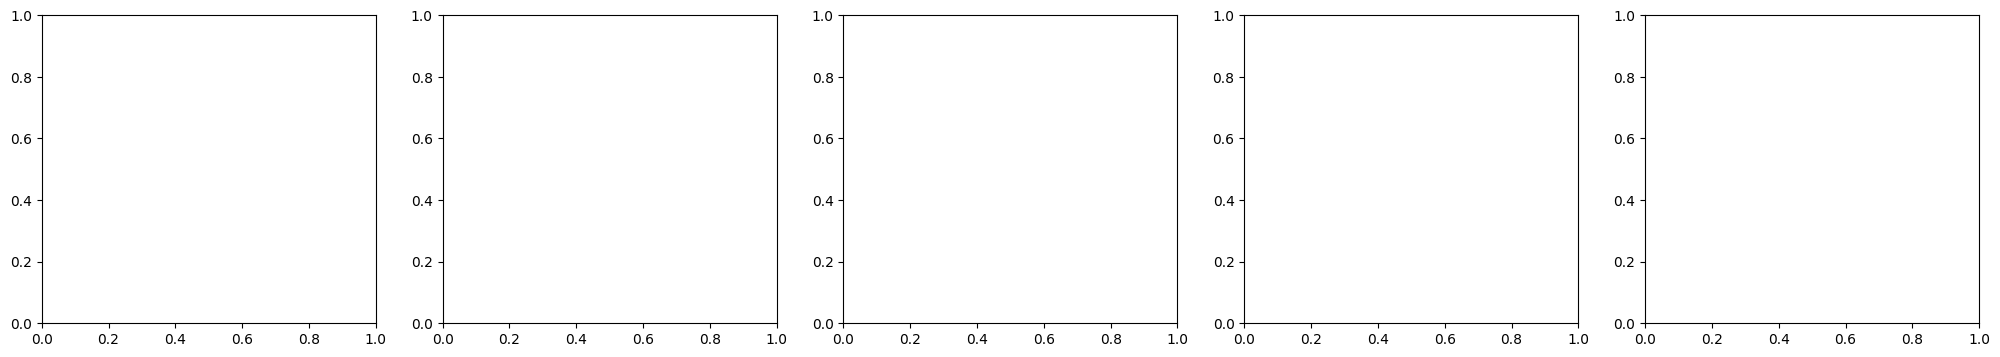

In [23]:
# ── 최종 FID 3모델 비교 바 차트 ───────────────────────────

def compute_final_fid_all(trained_G_all, fid_hist_all, db_type, datasets, miss_rates):
    """
    GAIN: 이미 수집된 fid_hist의 마지막 값 사용
    WGAN_FWAL / KD: imputed 결과로 최종 FID 직접 계산
    """
    records = []
    for ds in datasets:
        if ds not in trained_G_all[db_type]:
            continue
        for mr in miss_rates:
            if mr not in trained_G_all[db_type][ds]:
                continue
            slot   = trained_G_all[db_type][ds][mr]
            norm_p = slot['_norm_p']
            norm_x = slot['_norm_x']
            mask   = slot['_mask']

            for mname in ('GAIN', 'WGAN_FWAL', 'KD'):
                # GAIN은 fid_hist 마지막 값, 나머지는 직접 계산
                if mname == 'GAIN':
                    hist = fid_hist_all[db_type][ds][mr].get('GAIN', [])
                    fid_val = hist[-1] if hist else None
                else:
                    imp = slot['_imp'].get(mname)
                    if imp is None:
                        fid_val = None
                    else:
                        imp_norm, _ = normalization(imp, norm_p)
                        real_vals = norm_x[mask == 0].reshape(-1, 1)
                        fake_vals = imp_norm[mask == 0].reshape(-1, 1)
                        fid_val   = compute_fid(real_vals, fake_vals)

                records.append({
                    'dataset'  : ds,
                    'miss_rate': mr,
                    'model'    : mname,
                    'fid_final': fid_val,
                })
    return pd.DataFrame(records)


def plot_final_fid_bars(fid_df, datasets, miss_rates, title_prefix='', save_path=None):
    """
    데이터셋별 서브플롯, 결측률별 그룹 바 차트로 3모델 최종 FID 비교.
    """
    COLORS = {'GAIN': 'steelblue', 'WGAN_FWAL': 'seagreen', 'KD': 'darkorange'}
    models = ['GAIN', 'WGAN_FWAL', 'KD']
    n_ds   = len(datasets)
    n_mr   = len(miss_rates)
    x      = np.arange(n_mr)
    width  = 0.25

    fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 4), sharey=False)
    if n_ds == 1:
        axes = [axes]

    for ax, ds in zip(axes, datasets):
        sub = fid_df[fid_df['dataset'] == ds]
        for i, model in enumerate(models):
            msub = sub[sub['model'] == model].sort_values('miss_rate')
            vals = [msub[msub['miss_rate'] == mr]['fid_final'].values[0]
                    if not msub[msub['miss_rate'] == mr].empty else np.nan
                    for mr in miss_rates]
            bars = ax.bar(x + i * width, vals, width,
                          label=model, color=COLORS[model], alpha=0.85)
            for bar, v in zip(bars, vals):
                if not np.isnan(v):
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() * 1.02,
                            f'{v:.3f}', ha='center', va='bottom', fontsize=7)

        ax.set_title(ds, fontsize=10, fontweight='bold')
        ax.set_xticks(x + width)
        ax.set_xticklabels([f'{mr}' for mr in miss_rates], fontsize=8)
        ax.set_xlabel('Missing Rate')
        ax.set_ylabel('Final FID ↓')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'{title_prefix} — Final FID 3모델 비교',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()


# Light DB 최종 FID
print('\n[Final FID] Light DB — 3모델 비교')
fid_final_df_light = compute_final_fid_all(
    trained_G_all, fid_hist_all, 'light', DATASETS, MISS_RATES)
plot_final_fid_bars(
    fid_final_df_light, DATASETS, MISS_RATES,
    title_prefix='Light DB',
    save_path=os.path.join(ADV_SAVE_DIR, 'light', 'final_fid_bars.png')
)

# Heavy DB 최종 FID
if trained_G_all['heavy']:
    print('\n[Final FID] Heavy DB — 3모델 비교')
    heavy_ds_list = list(trained_G_all['heavy'].keys())
    fid_final_df_heavy = compute_final_fid_all(
        trained_G_all, fid_hist_all, 'heavy', heavy_ds_list, HEAVY_MISS_RATES)
    plot_final_fid_bars(
        fid_final_df_heavy, heavy_ds_list, HEAVY_MISS_RATES,
        title_prefix='Heavy DB',
        save_path=os.path.join(ADV_SAVE_DIR, 'heavy', 'final_fid_bars.png')
    )